# Egypt real estate prices: the numbers

Every number in the README, on the two SVG pictures, on the project card and in the Power BI checks
comes from this notebook. It reads the warehouse after a weekly run: start the stack
(`docker compose up -d`), let the `egypt_real_estate_prices` DAG finish, then run this notebook top
to bottom. Each measure lands in `numbers`; the last cells write `analysis/numbers.json` and then
fill the README and the SVGs from that file, so no number is typed by hand.

Each section states its grain: what one row of its table is.

In [1]:
import json
import os
import re
import sys
import warnings
from datetime import date
from decimal import ROUND_HALF_UP, Decimal
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import psycopg

# requests warns at import when urllib3 or chardet is newer than it knows; the notice names a local path.
warnings.filterwarnings("ignore", message=r"urllib3 .* doesn't match a supported version")
import requests  # noqa: E402

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))
from config import load_config  # noqa: E402  every client value comes from config/client.yaml

cfg = load_config()
CLIENT, CURRENCY, MIN_N = cfg["client"]["name"], cfg["client"]["currency"], cfg["rules"]["min_group_size"]
for line in (ROOT / ".env").read_text().splitlines():  # the warehouse password, and the ports if not the default
    if "=" in line and not line.startswith("#"):
        key, value = line.split("=", 1)
        os.environ.setdefault(key, value)

conn = psycopg.connect(host="127.0.0.1", port=os.environ.get("WAREHOUSE_PORT", "5451"), dbname="prices", user="prices",
                       password=os.environ["WAREHOUSE_PASSWORD"])


def query(sql, *params):
    with conn.cursor() as cur:
        cur.execute(sql, params)
        rows = [[float(v) if isinstance(v, Decimal) else v for v in row] for row in cur.fetchall()]
        return pd.DataFrame(rows, columns=[c.name for c in cur.description])


def half_up(value, places):
    """Round half away from zero, as the slots are written (Python's round() rounds half to even)."""
    return Decimal(str(value)).quantize(Decimal(1).scaleb(-places), rounding=ROUND_HALF_UP)


def pct(value, signed=False):
    return f"{half_up(value, 1):{'+' if signed else ''}}"


numbers = {}  # every measure lands here; numbers.json is written from it at the end



def slot(area_id):
    """An area's name in the README and SVG slots (docs/notebook-slots.md): its id with _ for -."""
    return area_id.replace("-", "_")


# Dark charts to sit beside the dark SVGs (report.chart_colours): one colour per site in fixed order,
# and one kept for our units only.
colours = cfg["report"]["chart_colours"]
# Charts use the README's navy and teal look; the Power BI theme keeps client.yaml's colours.
colours = {**colours, "surface": "#0F172A", "sites": ["#2DD4BF", "#E2E8F0", "#A78BFA", "#94A3B8", "#F472B6", "#475569"],
           "scale": ["#1E293B", "#0F766E"]}
SURFACE, INK, MUTED, GRID, OURS = (colours[k] for k in ("surface", "text", "muted", "grid", "ours"))
SITE_COLOURS = colours["sites"]
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": INK,
    "axes.edgecolor": GRID, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 14, "axes.titlelocation": "left", "axes.titlecolor": INK,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 11, "figure.dpi": 110, "savefig.bbox": "tight", "savefig.pad_inches": 0.3,
})

## 1. The run week and its rows

Grain: one row of `gold.fact_listing_price` is one site, listing and run week. The latest run week
is the newest week in `gold.dim_week`. The loader's counts must reconcile three ways before anything
else is measured: the fact rows of the week, the week's rows in `silver.price_observation` less those
quarantined in the same week (silver keeps every observed price; gold leaves out a price that fails
the checks), and the saved rows in `silver.run_log` (one row per site, area asked and run week). An
empty or partial week stops the notebook here.

In [2]:
latest_week = query("SELECT max(week_key) AS week FROM gold.dim_week").week[0]
assert latest_week is not None, "gold.dim_week is empty: no run has been built"

history = query("SELECT count(*) AS prices, count(DISTINCT run_week) AS weeks, min(run_week) AS first_week,"
                " max(run_week) AS last_week FROM silver.price_observation").iloc[0]
week = query("SELECT count(*) AS listings, count(DISTINCT site_key) AS sites, count(DISTINCT area_key) AS areas"
             " FROM gold.fact_listing_price WHERE week_key = %s", latest_week).iloc[0]
pooled_week = query("SELECT count(*) AS n FROM gold.pooled_listing_price WHERE week_key = %s", latest_week).n[0]
week_prices = query("""
    SELECT count(*) AS n FROM silver.price_observation o
    WHERE o.run_week = %s AND NOT EXISTS (SELECT 1 FROM silver.quarantine q WHERE q.run_week = o.run_week
                                          AND q.source = o.source AND q.payload->>'source_listing_id' = o.listing_id)
""", latest_week).n[0]
run_log = query("SELECT * FROM silver.run_log WHERE run_week = %s", latest_week)

assert week.listings > 0, f"no listing in gold for {latest_week}: the run loaded nothing"
assert history.last_week == latest_week, "silver and gold disagree on the latest run week"
assert week.listings == week_prices == run_log.rows_saved.sum(), (week.listings, week_prices, run_log.rows_saved.sum())
assert (run_log.rows_parsed == run_log.rows_skipped + run_log.rows_duplicate + run_log.rows_saved
        + run_log.rows_quarantined).all(), "a run_log row does not reconcile"

numbers.update(
    latest_run_week=latest_week.isoformat(), first_run_week=history.first_week.isoformat(),
    run_weeks=int(history.weeks), price_observations=int(history.prices),
    asking_prices_kept=int(week.listings), listings_compared=int(pooled_week), sites_read=int(week.sites), areas_read=int(week.areas),
    rows_parsed=int(run_log.rows_parsed.sum()), rows_skipped=int(run_log.rows_skipped.sum()),
    rows_duplicate=int(run_log.rows_duplicate.sum()), rows_saved=int(run_log.rows_saved.sum()),
)
numbers["run_weeks_phrase"] = f"{numbers['run_weeks']:,} weekly run{'' if numbers['run_weeks'] == 1 else 's'}"
print(f"{CLIENT}, run week {latest_week}: {pooled_week:,} competing listings ({week.listings:,} asking prices) from {week.sites} sites "
      f"in {week.areas} areas; "
      f"{history.prices:,} asking prices kept over {history.weeks} run week(s)")
print(f"run_log: {numbers['rows_parsed']:,} rows parsed = {numbers['rows_skipped']:,} skipped + "
      f"{numbers['rows_duplicate']:,} duplicates + {numbers['rows_saved']:,} saved + "
      f"{int(run_log.rows_quarantined.sum()):,} quarantined")

Demo developer, run week 2026-10-04: 5,619 competing listings (5,757 asking prices) from 6 sites in 6 areas; 5,757 asking prices kept over 1 run week(s)
run_log: 6,854 rows parsed = 935 skipped + 121 duplicates + 5,757 saved + 41 quarantined


## 2. Listings per site and area

Grain: one cell is one site and one area, latest run week, counted in `gold.fact_listing_price`.
The area is the listing's own area, which can differ from the area its search asked for
(section 3 counts by the area asked, so the two tables differ cell by cell and agree in total).

In [3]:
sites = query("SELECT site_key, source, name FROM gold.dim_site ORDER BY site_key")
areas = query("SELECT area_id, name FROM gold.dim_area ORDER BY area_key")
listings = query("""
    SELECT s.source, a.area_id, count(*) AS listings
    FROM gold.fact_listing_price f JOIN gold.dim_site s USING (site_key) JOIN gold.dim_area a USING (area_key)
    WHERE f.week_key = %s GROUP BY 1, 2
""", latest_week)
grid = listings.pivot_table(index="area_id", columns="source", values="listings", aggfunc="sum", fill_value=0)
grid = grid.reindex(index=areas.area_id, columns=sites.source, fill_value=0)
assert grid.values.sum() == numbers["asking_prices_kept"]

numbers["listings_by_site"] = {s: int(n) for s, n in grid.sum().items()}
numbers["listings_by_area"] = {slot(a): int(n) for a, n in grid.sum(axis=1).items()}
numbers["listings_by_site_and_area"] = {s: {slot(a): int(grid.at[a, s]) for a in grid.index} for s in grid.columns}
shown = grid.rename(index=dict(zip(areas.area_id, areas.name)), columns=dict(zip(sites.source, sites.name)))
shown.loc["All areas"] = shown.sum()
shown.assign(**{"All sites": shown.sum(axis=1)})

source,realestate.eg,Property Finder Egypt,Dubizzle Egypt,Nawy,Bayut Egypt,Aqarmap,All sites
area_id,,,,,,,
New Cairo,151,178,359,126,24,101,939
New Capital,101,158,360,116,24,115,874
Sheikh Zayed,168,155,354,141,24,123,965
6th of October,154,155,359,157,24,128,977
North Coast,183,153,358,158,23,144,1019
Mostakbal City,178,159,360,152,24,110,983
All areas,935,958,2150,850,143,721,5757


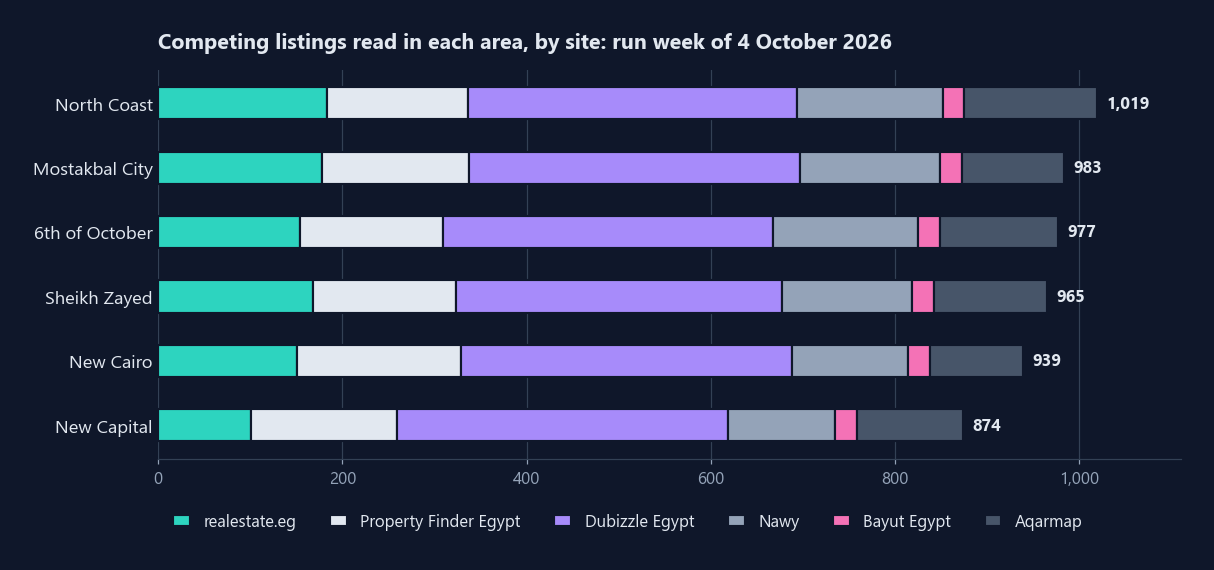

In [4]:
area_name = dict(zip(areas.area_id, areas.name))
order = grid.sum(axis=1).sort_values().index  # the largest area on top
fig, ax = plt.subplots(figsize=(12, 4.6))
left = pd.Series(0, index=order)
for colour, source, name in zip(SITE_COLOURS, sites.source, sites.name):
    ax.barh([area_name[a] for a in order], grid.loc[order, source], left=left, height=0.5, color=colour,
            edgecolor=SURFACE, linewidth=1.4, label=name)
    left += grid.loc[order, source]
for y, total in enumerate(left):
    ax.text(total + left.max() * 0.01, y, f"{total:,}", va="center", color=INK, fontweight="bold")
ax.set_xlim(0, left.max() * 1.09)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:,.0f}")
ax.xaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0, labelsize=12)
ax.set_title(f"Competing listings read in each area, by site: run week of {latest_week.day} {latest_week:%B %Y}", pad=14)
ax.legend(ncol=6, frameon=False, loc="upper left", bbox_to_anchor=(0, -0.1), handlelength=1, labelcolor=INK)
fig.savefig(ROOT / "docs" / "listings-by-area.png")

## 3. Coverage: listings read against each site's own count

Grain: one row is one site, one area asked and one run week (`silver.run_log`). `stated_total` is
the number of results the site's own search page says it holds; `rows_parsed` is the listings the
run read from the pages it opened; `rows_saved` is what reached silver after the checks
(residential, inside our six areas, not a duplicate, not quarantined). Coverage is `rows_parsed`
against `stated_total`. Each site counts its own way (some count every property type, some count
projects rather than units), so the percentages compare a site with itself, not sites with each other.

In [5]:
coverage = query("""
    SELECT s.name AS site, r.source, a.name AS area, r.stated_total, r.pages_read, r.rows_parsed, r.rows_saved
    FROM silver.run_log r JOIN gold.dim_site s USING (source) JOIN silver.area a USING (area_id)
    WHERE r.run_week = %s ORDER BY s.site_key, a.area_id
""", latest_week)
print(f"{coverage.stated_total.isna().sum()} of {len(coverage)} site and area searches gave no stated count")
coverage["read_pct"] = (coverage.rows_parsed / coverage.stated_total * 100).round(2)

by_site = coverage.groupby(["source", "site"], sort=False)[["stated_total", "rows_parsed", "rows_saved"]].sum()
by_site["read_pct"] = (by_site.rows_parsed / by_site.stated_total * 100).round(2)
numbers["coverage_by_site"] = {source: {"stated_total": int(r.stated_total), "rows_parsed": int(r.rows_parsed),
                                        "rows_saved": int(r.rows_saved), "read_pct": float(r.read_pct)}
                               for (source, _), r in by_site.iterrows()}
display(by_site)
coverage

0 of 36 site and area searches gave no stated count


,,stated_total,rows_parsed,rows_saved,read_pct
source,site,,,,
realestate,realestate.eg,13242,1650,935,12.46
propertyfinder,Property Finder Egypt,124083,983,958,0.79
dubizzle,Dubizzle Egypt,120186,2160,2150,1.80
nawy,Nawy,18636,1104,850,5.92
bayut,Bayut Egypt,123108,144,143,0.12
aqarmap,Aqarmap,41309,813,721,1.97


,site,source,area,stated_total,pages_read,rows_parsed,rows_saved,read_pct
0,realestate.eg,realestate,Mostakbal City,630,182,200,178,31.75
1,realestate.eg,realestate,New Capital,3644,109,400,101,10.98
2,realestate.eg,realestate,New Cairo,5456,158,350,151,6.41
3,realestate.eg,realestate,North Coast,1097,188,200,183,18.23
4,realestate.eg,realestate,Sheikh Zayed,1240,172,200,168,16.13
5,realestate.eg,realestate,6th of October,1175,160,300,154,25.53
6,Property Finder Egypt,propertyfinder,Mostakbal City,6555,8,161,159,2.46
7,Property Finder Egypt,propertyfinder,New Capital,4535,8,161,158,3.55
8,Property Finder Egypt,propertyfinder,New Cairo,49515,9,180,178,0.36
9,Property Finder Egypt,propertyfinder,North Coast,27450,8,160,153,0.58


## 4. Price per m² in each area

Grain: one row is one area, latest run week, pooled over the six sites and over every residential
unit type: the median asking price per m² and the middle half of the listings (25th to 75th
percentile), `percentile_cont` over `gold.pooled_listing_price` (the facts without the Bayut Egypt
rows that copy a Dubizzle ad). These are measured market numbers.
The second table is `gold.area_benchmark` (one row per area and unit type), the medians our units
are compared with in section 5.

In [6]:
market = query("""
    SELECT a.area_id, a.name AS area, count(*) AS listings,
           round(percentile_cont(0.25) WITHIN GROUP (ORDER BY f.price_per_m2)::numeric, 2) AS p25_m2,
           round(percentile_cont(0.5) WITHIN GROUP (ORDER BY f.price_per_m2)::numeric, 2) AS median_m2,
           round(percentile_cont(0.75) WITHIN GROUP (ORDER BY f.price_per_m2)::numeric, 2) AS p75_m2
    FROM gold.pooled_listing_price f JOIN gold.dim_area a USING (area_key)
    WHERE f.week_key = %s GROUP BY 1, 2 ORDER BY median_m2 DESC
""", latest_week)
for r in market.itertuples():
    numbers[f"median_m2_{slot(r.area_id)}"] = r.median_m2
    numbers[f"p25_m2_{slot(r.area_id)}"] = r.p25_m2
    numbers[f"p75_m2_{slot(r.area_id)}"] = r.p75_m2
display(market)
query("""
    SELECT a.name AS area, t.unit_type, b.listings, b.median_price_per_m2, b.p25_price_per_m2, b.p75_price_per_m2
    FROM gold.area_benchmark b JOIN gold.dim_area a USING (area_key) JOIN gold.dim_property_type t USING (type_key)
    ORDER BY a.name, t.unit_type
""")

,area_id,area,listings,p25_m2,median_m2,p75_m2
0,north-coast,North Coast,1000,70000.00,113511.10,155729.40
1,new-cairo,New Cairo,916,54600.88,76142.13,104602.12
2,sheikh-zayed,Sheikh Zayed,941,42211.06,62068.97,93333.33
3,sixth-october-city,6th of October,953,40586.47,58148.89,87083.33
4,mostakbal-city,Mostakbal City,959,40896.86,56311.21,75460.64
5,new-administrative-capital,New Capital,850,35008.07,53000.00,82189.32


,area,unit_type,listings,median_price_per_m2,p25_price_per_m2,p75_price_per_m2
0,6th of October,Apartment,395,53935.48,31936.12,89000.00
1,6th of October,Chalet,2,22884.62,22019.23,23750.00
2,6th of October,Duplex,28,58568.00,49750.00,87507.09
3,6th of October,iVilla,43,41015.63,37831.17,51165.90
4,6th of October,Loft,2,114545.66,112932.12,116159.19
5,6th of October,Penthouse,64,49518.98,44118.61,69401.20
6,6th of October,Studio,47,76403.51,52155.54,93826.19
7,6th of October,Town House,122,64825.58,53167.28,86741.07
8,6th of October,Twin House,66,66000.00,54371.98,85622.47
9,6th of October,Villa,184,67382.42,45132.08,91038.96


## Our units are generated

The client is not named, so its units are made up: `make_units.py` puts ten units in each area,
inside real compounds seen on the sites, and prices each at a seeded random 15% below to 15% above
the market median of its type in its area. **The gap numbers below (sections 5, 6 and 8) therefore
show the method, not a finding about a real seller.** The market numbers (listings, medians,
coverage, compounds, developers, quarantine) are measured from the sites.

## 5. Our units against the area median of their type

Grain of the first table: one row per unit of ours (`gold.unit_gap`): its price per m² against the
pooled median of the same unit type in the same area, latest run week; `gap_pct` is signed, + when
we ask more. Grain of the second: one row per area (`gold.area_gap`): the median of its units' gaps,
and `gap_rank` 1 for the widest gap in absolute terms. The median gap is recomputed here from the
unit rows and must match the view.

In [7]:
units = query("""
    SELECT g.unit_code, a.area_id, a.name AS area, t.unit_type, g.price_per_m2, g.median_price_per_m2,
           g.gap_pct, g.listings_compared, g.listings_cheaper
    FROM gold.unit_gap g JOIN gold.dim_area a USING (area_key) JOIN gold.dim_property_type t USING (type_key)
    ORDER BY a.name, g.unit_code
""")
our_units = query("SELECT count(*) AS n FROM gold.fact_our_unit").n[0]
area_gap = query("""
    SELECT a.area_id, a.name AS area, g.units, g.units_compared, g.median_gap_pct, g.pct_listings_cheaper, g.gap_rank
    FROM gold.area_gap g JOIN gold.dim_area a USING (area_key) ORDER BY g.gap_rank, a.name
""")
assert len(units) == our_units > 0
recomputed = units.groupby("area_id").gap_pct.median().reindex(area_gap.area_id)
assert ((recomputed.values - area_gap.median_gap_pct.values).__abs__() < 0.006).all(), "median gap differs from gold.area_gap"

numbers.update(our_units=int(our_units), units_without_comparison=int(units.gap_pct.isna().sum()),
               units_above_market=int((units.gap_pct > 0).sum()))
for r in area_gap.itertuples():
    numbers[f"gap_pct_{slot(r.area_id)}"] = r.median_gap_pct
    numbers[f"our_units_m2_{slot(r.area_id)}"] = sorted(units.loc[units.area_id == r.area_id, "price_per_m2"])
print(f"{our_units} units of ours, {numbers['units_without_comparison']} without a comparison, "
      f"{numbers['units_above_market']} asking more than the median of their type and area")
display(area_gap)
units

60 units of ours, 0 without a comparison, 35 asking more than the median of their type and area


,area_id,area,units,units_compared,median_gap_pct,pct_listings_cheaper,gap_rank
0,sixth-october-city,6th of October,10,10,7.38,50.96,1
1,sheikh-zayed,Sheikh Zayed,10,10,2.83,49.95,2
2,new-administrative-capital,New Capital,10,10,1.87,48.68,3
3,new-cairo,New Cairo,10,10,-0.73,53.32,4
4,mostakbal-city,Mostakbal City,10,10,-0.59,47.71,5
5,north-coast,North Coast,10,10,-0.05,48.07,6


,unit_code,area_id,area,unit_type,price_per_m2,median_price_per_m2,gap_pct,listings_compared,listings_cheaper
0,OCT-APT-01,sixth-october-city,6th of October,Apartment,49151.52,53935.48,-8.87,395,177
1,OCT-APT-02,sixth-october-city,6th of October,Apartment,46400.00,53935.48,-13.97,395,161
2,OCT-APT-03,sixth-october-city,6th of October,Apartment,58823.53,53935.48,9.06,395,227
3,OCT-APT-04,sixth-october-city,6th of October,Apartment,60774.19,53935.48,12.68,395,236
4,OCT-APT-05,sixth-october-city,6th of October,Apartment,53371.43,53935.48,-1.05,395,194
5,OCT-DUP-01,sixth-october-city,6th of October,Duplex,65888.89,58568.00,12.50,28,17
6,OCT-PH-01,sixth-october-city,6th of October,Penthouse,54088.89,49518.98,9.23,64,37
7,OCT-PH-02,sixth-october-city,6th of October,Penthouse,54451.61,49518.98,9.96,64,38
8,OCT-TH-01,sixth-october-city,6th of October,Town House,68520.00,64825.58,5.70,122,65
9,OCT-VIL-01,sixth-october-city,6th of October,Villa,66444.44,67382.42,-1.39,184,90


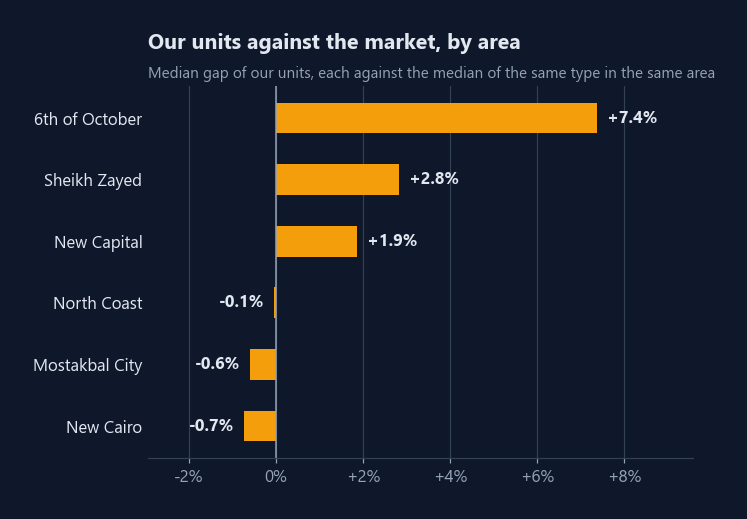

In [8]:
g = area_gap.sort_values("median_gap_pct")
fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.barh(g.area, g.median_gap_pct, height=0.5, color=OURS)
ax.axvline(0, color=MUTED, linewidth=1)
span = g.median_gap_pct.abs().max()
for y, v in enumerate(g.median_gap_pct):
    ax.text(v + (span * 0.03 if v >= 0 else -span * 0.03), y, f"{pct(v, signed=True)}%", va="center",
            ha="left" if v >= 0 else "right", color=INK, fontweight="bold")
ax.set_xlim(min(0, g.median_gap_pct.min()) - span * 0.3, max(0, g.median_gap_pct.max()) + span * 0.3)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:+.0f}%" if x else "0%")
ax.xaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_title("Our units against the market, by area", pad=24)
ax.text(0, 1.02, "Median gap of our units, each against the median of the same type in the same area", transform=ax.transAxes,
        color=MUTED, fontsize=10)
fig.savefig(ROOT / "docs" / "gap-by-area.png")

The picture `docs/price-gap-by-area.svg` puts every area on one price-per-m² scale. Its ends are
the lowest 25th percentile or unit price and the highest 75th percentile or unit price over all
areas, widened to the next 10,000 EGP. The band and the tick there are the pooled market of
section 4 (every type together), the dots are our units at their own price per m², and the gap
written beside each strip is the type-matched median gap above, so a dot can sit left of the tick
and still ask more than the median of its own type.

In [9]:
STEP = 10_000
low = min(market.p25_m2.min(), units.price_per_m2.min())
high = max(market.p75_m2.max(), units.price_per_m2.max())
numbers["scale_min_m2"] = int(low // STEP * STEP)
numbers["scale_max_m2"] = int(-(-high // STEP) * STEP)
print(f"Scale {numbers['scale_min_m2']:,} to {numbers['scale_max_m2']:,} {CURRENCY} per m²")

Scale 30,000 to 170,000 EGP per m²


## 6. Competing listings cheaper per m² than ours

Grain: one row per competing listing of the latest run week in an area and unit type where we have
at least one unit; listings of a type we do not sell in that area are left out of the denominator.
A listing counts as cheaper when its price per m² is below that of our median unit of the same type
in the same area (the definition in `docs/notebook-slots.md`). The listings are pooled over sites
(`gold.pooled_listing_price`, without the Bayut Egypt rows that copy a Dubizzle ad).
`gold.area_gap.pct_listings_cheaper` counts differently (every unit against every listing of its
type, summed), so it is kept beside it under its own name. The Power BI measure and checks C3 and C7
use the definition above over the same pooled listings, so they give the same numbers (section 13).

In [10]:
ours_median = units.groupby(["area_id", "unit_type"], as_index=False).price_per_m2.median()
ours_median = ours_median.rename(columns={"price_per_m2": "our_median_m2"})
competing = query("""
    SELECT a.area_id, t.unit_type, f.price_per_m2
    FROM gold.pooled_listing_price f JOIN gold.dim_area a USING (area_key) JOIN gold.dim_property_type t USING (type_key)
    WHERE f.week_key = %s
""", latest_week)
compared = competing.merge(ours_median, on=["area_id", "unit_type"])  # only the types we sell in each area
compared["cheaper"] = compared.price_per_m2 < compared.our_median_m2

by_area = compared.groupby("area_id").cheaper.agg(listings="size", cheaper="sum")
by_area["cheaper_pct"] = by_area.cheaper / by_area.listings * 100
by_type = compared.groupby("unit_type").cheaper.agg(listings="size", cheaper="sum")
by_type["cheaper_pct"] = by_type.cheaper / by_type.listings * 100

numbers.update(listings_in_our_types=int(len(compared)), listings_cheaper_than_ours=int(compared.cheaper.sum()),
               share_listings_cheaper_than_ours=compared.cheaper.mean() * 100)
for area_id, r in by_area.iterrows():
    numbers[f"share_cheaper_{slot(area_id)}"] = r.cheaper_pct
numbers["share_cheaper_by_type"] = by_type.cheaper_pct.to_dict()
numbers["gold_area_gap_pct_listings_cheaper"] = {slot(r.area_id): r.pct_listings_cheaper for r in area_gap.itertuples()}
print(f"{numbers['listings_cheaper_than_ours']:,} of {numbers['listings_in_our_types']:,} competing listings "
      f"({pct(numbers['share_listings_cheaper_than_ours'])}%) ask less per m² than our median unit of their type and area")
display(by_area.rename(index=area_name))
by_type

2,485 of 4,929 competing listings (50.4%) ask less per m² than our median unit of their type and area


,listings,cheaper,cheaper_pct
area_id,,,
Mostakbal City,921,432,46.905537
New Capital,813,430,52.890529
New Cairo,852,442,51.877934
North Coast,693,343,49.494949
Sheikh Zayed,857,434,50.641774
6th of October,793,404,50.945776


,listings,cheaper,cheaper_pct
unit_type,,,
Apartment,2049,986,48.121035
Chalet,458,224,48.908297
Duplex,190,91,47.894737
Penthouse,171,101,59.064327
Town House,547,283,51.736746
Twin House,288,146,50.694444
Villa,1226,654,53.344209


## 7. Compounds and developers covered

Grain: one row of `gold.dim_compound` is one area, compound and developer as the sites write them,
`Unknown` when a site names none. Covered means named (not `Unknown`) and with at least one listing
in `gold.fact_listing_price`; a compound name is counted once even when it appears in two areas. The
listings without a compound or a developer are counted for the latest run week.

In [11]:
covered = query("""
    SELECT count(DISTINCT c.compound) FILTER (WHERE c.compound <> 'Unknown') AS compounds,
           count(DISTINCT c.developer) FILTER (WHERE c.developer <> 'Unknown') AS developers,
           count(DISTINCT (c.area_id, c.compound)) FILTER (WHERE c.compound <> 'Unknown') AS area_compounds
    FROM gold.dim_compound c WHERE EXISTS (SELECT 1 FROM gold.fact_listing_price f WHERE f.compound_key = c.compound_key)
""").iloc[0]
named = query("""
    SELECT count(*) AS listings, count(*) FILTER (WHERE c.compound = 'Unknown') AS without_compound,
           count(*) FILTER (WHERE c.developer = 'Unknown') AS without_developer
    FROM gold.fact_listing_price f JOIN gold.dim_compound c USING (compound_key) WHERE f.week_key = %s
""", latest_week).iloc[0]
numbers.update(compounds_covered=int(covered.compounds), developers_covered=int(covered.developers),
               area_compounds_covered=int(covered.area_compounds),
               listings_without_compound=int(named.without_compound),
               listings_without_developer=int(named.without_developer))
print(f"{covered.compounds:,} compound names ({covered.area_compounds:,} area and compound pairs) from "
      f"{covered.developers:,} developers; of {named.listings:,} listings, {named.without_compound:,} name no compound "
      f"and {named.without_developer:,} no developer")
query("""
    SELECT a.name AS area, count(DISTINCT c.compound) FILTER (WHERE c.compound <> 'Unknown') AS compounds,
           count(DISTINCT c.developer) FILTER (WHERE c.developer <> 'Unknown') AS developers, count(*) AS listings
    FROM gold.fact_listing_price f JOIN gold.dim_compound c USING (compound_key) JOIN gold.dim_area a USING (area_key)
    WHERE f.week_key = %s GROUP BY a.name ORDER BY a.name
""", latest_week)

1,152 compound names (1,171 area and compound pairs) from 307 developers; of 5,757 listings, 656 name no compound and 3,572 no developer


,area,compounds,developers,listings
0,6th of October,247,88,977
1,Mostakbal City,91,43,983
2,New Cairo,295,81,939
3,New Capital,114,40,874
4,North Coast,223,90,1019
5,Sheikh Zayed,201,80,965


## 8. Price cuts by run week

Grain: one row of `gold.price_change` is one listing whose price per m² changed from its previous
run week; `is_cut` when it fell. A change needs two run weeks of the same listing.

In [12]:
per_week = query("""
    SELECT w.week_key, count(c.week_key) FILTER (WHERE c.is_cut) AS cuts, count(c.week_key) FILTER (WHERE NOT c.is_cut) AS rises
    FROM gold.dim_week w LEFT JOIN gold.price_change c USING (week_key) GROUP BY w.week_key ORDER BY w.week_key
""").set_index("week_key")
numbers.update(price_cuts=int(per_week.cuts[latest_week]), price_rises=int(per_week.rises[latest_week]),
               price_changes=int(query("SELECT count(*) AS n FROM gold.price_change").n[0]))
if len(per_week) == 1:
    print(f"Only one run week ({latest_week}): no listing has an earlier price, so "
          f"{numbers['price_cuts']} cuts and {numbers['price_rises']} rises. Cuts appear from the second weekly run.")
per_week

Only one run week (2026-10-04): no listing has an earlier price, so 0 cuts and 0 rises. Cuts appear from the second weekly run.


,cuts,rises
week_key,,
2026-10-04,0,0


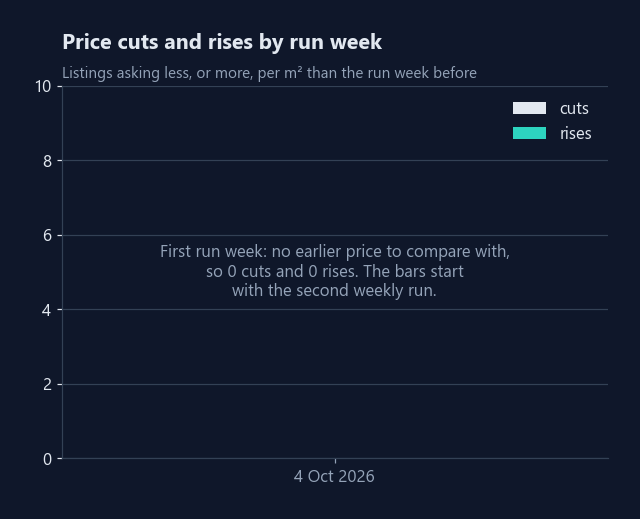

In [13]:
fig, ax = plt.subplots(figsize=(6.4, 4.4))
x = range(len(per_week))
ax.bar([i - 0.15 for i in x], per_week.cuts, width=0.3, color=SITE_COLOURS[1], label="cuts")
ax.bar([i + 0.15 for i in x], per_week.rises, width=0.3, color=SITE_COLOURS[0], label="rises")
ax.set_xticks(list(x), [f"{w.day} {w:%b %Y}" for w in per_week.index])
ax.set_xlim(-0.8, len(per_week) - 0.2)
ax.set_ylim(0, max(10, per_week.values.max() * 1.15))
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.yaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.set_title("Price cuts and rises by run week", pad=24)
ax.text(0, 1.02, "Listings asking less, or more, per m² than the run week before", transform=ax.transAxes,
        color=MUTED, fontsize=10)
ax.legend(frameon=False, loc="upper right", labelcolor=INK)
if len(per_week) == 1:
    ax.text(0.5, 0.5, f"First run week: no earlier price to compare with,\nso {numbers['price_cuts']} cuts and "
            f"{numbers['price_rises']} rises. The bars start\nwith the second weekly run.",
            transform=ax.transAxes, ha="center", va="center", color=MUTED, fontsize=11)
fig.savefig(ROOT / "docs" / "price-cuts-by-week.png")

## 9. The widest gap

Grain: one row per area (`gold.area_gap`); rank 1 is the area whose median gap is furthest from 0
in either direction. A tie for rank 1 stops the notebook, so the README never names one area of two.

In [14]:
widest = area_gap[area_gap.gap_rank == 1]
assert len(widest) == 1, f"{len(widest)} areas share rank 1: {list(widest.area)}"
numbers.update(widest_gap_area=widest.area.iat[0], widest_gap_pct=widest.median_gap_pct.iat[0])
print(f"Widest gap: {numbers['widest_gap_area']}, {pct(numbers['widest_gap_pct'], signed=True)}% against the median of the same type in the same area")

Widest gap: 6th of October, +7.4% against the median of the same type in the same area


## 10. Quarantine

Grain: one row of `silver.quarantine` is one rejected row and reason in a run week. The share is
over every row that passed or failed the checks, all run weeks: `rows_saved` plus `rows_quarantined`
in `silver.run_log` (a price quarantined after it was saved stays in `silver.price_observation`, so
that table plus the quarantine would count it twice).

In [15]:
quarantine = query("SELECT run_week, source, reason, count(*) AS rows FROM silver.quarantine GROUP BY 1, 2, 3 ORDER BY 1, 2, 3")
quarantined = int(quarantine.rows.sum())
assert quarantine[quarantine.run_week == latest_week].rows.sum() == run_log.rows_quarantined.sum(), \
    "silver.quarantine and silver.run_log disagree on the week's rejected rows"
rows_checked = int(query("SELECT sum(rows_saved + rows_quarantined) AS n FROM silver.run_log").n[0])
numbers.update(quarantined_rows=quarantined, rows_checked=rows_checked,
               quarantine_share_pct=quarantined / rows_checked * 100,
               quarantine_by_reason={k: int(v) for k, v in quarantine.groupby("reason").rows.sum().items()})
print(f"{quarantined} rows set aside, {pct(numbers['quarantine_share_pct'])}% of "
      f"{rows_checked:,} rows checked")
quarantine

41 rows set aside, 0.7% of 5,798 rows checked


,run_week,source,reason,rows
0,2026-10-04,aqarmap,"price per m² outside 10,000 to 400,000",2
1,2026-10-04,dubizzle,"price per m² outside 10,000 to 400,000",2
2,2026-10-04,nawy,price missing or <= 0,11
3,2026-10-04,nawy,"price per m² outside 10,000 to 400,000",8
4,2026-10-04,nawy,unknown type,1
5,2026-10-04,propertyfinder,"price per m² outside 10,000 to 400,000",16
6,2026-10-04,realestate,"price per m² outside 10,000 to 400,000",1


## 11. Run time

Grain: one Airflow DAG run. The latest successful run of `egypt_real_estate_prices`, start to end,
from the Airflow REST API (`/auth/token`, then `/api/v2/dags/.../dagRuns`). Its task tries are
listed: a retried task's time is inside the run's time, and an extract that finds the week's pages
already saved reads them from disk, so this is not how long a live read of the sites takes.

The README gives an estimate instead. Grain of the second table: one row per automated site
(realestate, propertyfinder, dubizzle, nawy), latest run week: the pages it read (`silver.run_log`
`pages_read`, summed over its areas) times the wait between two requests (`DELAY` in `tracker.py`
and `sites.py`). The four extracts run in parallel, so the estimate is the slowest site's. Retries
and the browser sites (Bayut, Aqarmap, read by hand before the run) are not in it.


In [16]:
AIRFLOW = f"http://127.0.0.1:{os.environ.get('AIRFLOW_PORT', '8101')}"
headers = {"Authorization": f"Bearer {requests.get(f'{AIRFLOW}/auth/token', timeout=30).json()['access_token']}"}
response = requests.get(f"{AIRFLOW}/api/v2/dags/egypt_real_estate_prices/dagRuns", headers=headers, timeout=30,
                        params={"state": "success", "order_by": "-end_date", "limit": 1})
response.raise_for_status()
assert response.json()["dag_runs"], "Airflow has no successful run of egypt_real_estate_prices"
run = response.json()["dag_runs"][0]
seconds = (pd.Timestamp(run["end_date"]) - pd.Timestamp(run["start_date"])).total_seconds()
numbers.update(run_id=run["dag_run_id"], run_seconds=seconds, run_minutes=seconds / 60)
print(f"{run['dag_run_id']}: {run['start_date']} to {run['end_date']}, {seconds:,.3f} seconds")
tasks = requests.get(f"{AIRFLOW}/api/v2/dags/egypt_real_estate_prices/dagRuns/{run['dag_run_id']}/taskInstances",
                     headers=headers, timeout=30).json()["task_instances"]
pd.DataFrame(tasks)[["task_id", "state", "try_number", "start_date", "end_date", "duration"]].sort_values("start_date")

manual__2026-10-05T10:19:20.982518+00:00: 2026-10-05T10:19:21.197678Z to 2026-10-05T10:22:56.403852Z, 215.206 seconds


,task_id,state,try_number,start_date,end_date,duration
0,extract_realestate,success,1,2026-10-05T10:19:21.896255Z,2026-10-05T10:19:43.722473Z,21.826218
3,extract_nawy,success,1,2026-10-05T10:19:21.920625Z,2026-10-05T10:19:46.695987Z,24.775362
1,extract_propertyfinder,success,1,2026-10-05T10:19:21.924582Z,2026-10-05T10:19:47.485444Z,25.560862
2,extract_dubizzle,success,1,2026-10-05T10:19:22.103721Z,2026-10-05T10:19:46.705359Z,24.601638
4,load_silver,success,1,2026-10-05T10:19:48.290789Z,2026-10-05T10:22:48.087570Z,179.796781
5,build_gold,success,1,2026-10-05T10:22:49.496900Z,2026-10-05T10:22:53.433661Z,3.936761
6,report,success,1,2026-10-05T10:22:54.370367Z,2026-10-05T10:22:55.541112Z,1.170745


In [17]:
from browser_sites import BROWSER_SITES  # noqa: E402  the sites read by hand, not by Airflow

pace = {s["id"]: s["pace_seconds"] for s in cfg["sites"]}  # each site's wait between two requests
AUTOMATED = [s for s in pace if s not in BROWSER_SITES]
pages = query("SELECT source, sum(pages_read) AS pages FROM silver.run_log WHERE run_week = %s AND source = ANY(%s)"
              " GROUP BY source ORDER BY pages DESC, source", latest_week, AUTOMATED).set_index("source").pages
assert sorted(pages.index) == sorted(AUTOMATED) and (pages > 0).all(), f"pages read this week: {pages.to_dict()}"
minutes = (pages * pages.index.map(pace) / 60).sort_values(ascending=False, kind="stable")
slowest = minutes.index[0]
numbers.update(live_read_pages_by_site={s: int(n) for s, n in pages.items()}, live_read_request_seconds=pace[slowest],
               live_read_slowest_site=slowest, live_read_minutes_estimate=int(pages[slowest]) * pace[slowest] / 60)
print(f"Live read estimate: {pages[slowest]:,} pages on {slowest} x {pace[slowest]} s / 60 = "
      f"{numbers['live_read_minutes_estimate']:.3f} minutes")
pages.to_frame().assign(minutes=minutes)


Live read estimate: 969 pages on realestate x 2.5 s / 60 = 40.375 minutes


,pages,minutes
source,,
realestate,969,40.375000
nawy,92,3.833333
propertyfinder,49,2.041667
dubizzle,48,2.000000


## 12. Insights

What the market numbers say beyond the core measures, for the latest run week. Every item states its
grain, uses medians (never means), states n for every group and leaves out any group of fewer than
10 listings, saying how many were left out. Numbers pooled over sites read `gold.pooled_listing_price`:
the facts without the Bayut Egypt rows that copy a Dubizzle ad (the same listing id in the same week).
Each item writes its numbers to `numbers["insights"]`, draws one chart `docs/insight-<n>-<slug>.png`
and builds one plain sentence from its numbers. They describe asking prices side by side; none of
them shows a cause.

In [18]:
import gzip
import unicodedata

import numpy as np
from matplotlib.colors import LinearSegmentedColormap

from browser_sites import flight  # noqa: E402  (Aqarmap's page data, item 6)

insights = numbers["insights"] = {}

FACTS = """
    SELECT s.source, s.name AS site, f.listing_id, a.area_id, a.name AS area, t.unit_type, c.compound, c.developer,
           f.asking_price, f.size_m2, f.price_per_m2, f.bedrooms
    FROM {table} f JOIN gold.dim_site s USING (site_key) JOIN gold.dim_area a USING (area_key)
    JOIN gold.dim_property_type t USING (type_key) JOIN gold.dim_compound c USING (compound_key)
    WHERE f.week_key = %s ORDER BY s.site_key, f.listing_id
"""
facts = query(FACTS.format(table="gold.fact_listing_price"), latest_week)
pooled = query(FACTS.format(table="gold.pooled_listing_price"), latest_week)
# The view's rule recomputed here: a Bayut row whose listing id is a Dubizzle row of the same week.
mirror = facts.source.eq("bayut") & facts.listing_id.isin(facts.listing_id[facts.source.eq("dubizzle")])
assert len(facts) == numbers["asking_prices_kept"] and len(pooled) > 0, (len(facts), len(pooled))
assert facts.loc[~mirror, ["source", "listing_id"]].reset_index(drop=True).equals(pooled[["source", "listing_id"]]), \
    "gold.pooled_listing_price does not leave out exactly the Bayut rows that copy a Dubizzle ad"
numbers["pooled_listings"] = len(pooled)
assert numbers["listings_compared"] == numbers["pooled_listings"], (numbers["listings_compared"], len(pooled))
numbers["pooled_listings_by_area"] = {slot(a): int(n) for a, n in pooled.area_id.value_counts().items()}
print(f"{len(pooled):,} pooled listings: {len(facts):,} in gold less {int(mirror.sum())} Bayut rows that copy a Dubizzle ad")


def medians(frame, by, value="price_per_m2"):
    """n, quartiles and median of `value` per group; the groups under MIN_N rows come back apart."""
    stats = (frame.groupby(by, observed=True)[value]
             .agg(n="size", p25=lambda v: v.quantile(0.25), median="median", p75=lambda v: v.quantile(0.75))
             .reset_index())
    return stats[stats.n >= MIN_N].reset_index(drop=True), stats[stats.n < MIN_N].reset_index(drop=True)


def plain(value):
    """A pandas or numpy value as plain JSON; a missing number is None."""
    value = value.item() if hasattr(value, "item") else value
    return None if isinstance(value, float) and value != value else value


def rows(frame):
    return [{key: plain(value) for key, value in row.items()} for row in frame.to_dict("records")]


def egp(value):
    return f"{half_up(value, 0):,} {CURRENCY}"


def skipped(small, noun):
    """'2 groups under 10 listings skipped (11 listings)', or 'no group skipped'."""
    if small.empty:
        return f"no {noun} skipped"
    return f"{len(small):,} {noun}{'' if len(small) == 1 else 's'} under {MIN_N} listings skipped ({int(small.n.sum()):,} listings)"


def label(text, width=34):
    """A name as the site writes it, without invisible direction marks, cut to fit a chart."""
    text = "".join(ch for ch in str(text) if unicodedata.category(ch) != "Cf")
    return text if len(text) <= width else text[:width - 3].rstrip() + "..."


def chart(title, subtitle, size=(6.4, 4.4)):
    fig, ax = plt.subplots(figsize=size)
    ax.set_title(title, pad=24)
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, color=MUTED, fontsize=10)
    return fig, ax


def bars_look(ax):
    ax.xaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)


SEQUENTIAL = LinearSegmentedColormap.from_list("scale", colours["scale"])
SEQUENTIAL.set_bad(SURFACE)


def heatmap(ax, kept, small, row, col, row_order, col_order):
    """Median per cell with its n; a group under MIN_N listings reads 'n < 10', no listing stays empty."""
    grid = kept.pivot(index=row, columns=col, values="median").reindex(index=row_order, columns=col_order)
    count = kept.pivot(index=row, columns=col, values="n").reindex(index=row_order, columns=col_order)
    few = small.pivot(index=row, columns=col, values="n").reindex(index=row_order, columns=col_order)
    ax.imshow(grid.to_numpy(dtype=float), cmap=SEQUENTIAL, aspect="auto")
    for i in range(len(row_order)):
        for j in range(len(col_order)):
            if pd.notna(grid.iat[i, j]):
                ax.text(j, i, f"{grid.iat[i, j] / 1000:,.0f}k\nn {int(count.iat[i, j]):,}", ha="center", va="center",
                        color=INK, fontsize=9)
            elif pd.notna(few.iat[i, j]):
                ax.text(j, i, f"n < {MIN_N}", ha="center", va="center", color=MUTED, fontsize=8)
    ax.set_xticks(range(len(col_order)), [str(c) for c in col_order])
    ax.set_yticks(range(len(row_order)), list(row_order))
    ax.set_xticks(np.arange(-0.5, len(col_order)), minor=True)
    ax.set_yticks(np.arange(-0.5, len(row_order)), minor=True)
    ax.grid(which="minor", color=SURFACE, linewidth=3)
    ax.tick_params(which="both", length=0)
    for side in ax.spines.values():
        side.set_visible(False)


def save(fig, n, slug):
    path = f"docs/insight-{n}-{slug}.png"
    fig.savefig(ROOT / path)
    return path

5,619 pooled listings: 5,757 in gold less 138 Bayut rows that copy a Dubizzle ad


### Insight 1. Area ranking

Grain: one row per area, latest run week, pooled over sites and unit types. The median asking price
per m² and its interquartile range (25th to 75th percentile) per area, and each area's premium over
the cheapest area's median, in percent. Section 4 reads the same pooled rows in SQL; the medians
must agree.

North Coast has the highest median asking price per m² (113,511 EGP, n = 1,000), 114.2% above New Capital, the lowest (53,000 EGP, n = 850); no area skipped.


,area,n,p25,median,p75,iqr,premium_pct
0,North Coast,1000,70000.000,113511.095,155729.4025,85729.4025,114.171877
1,New Cairo,916,54600.880,76142.130,104602.1200,50001.2400,43.664396
2,Sheikh Zayed,941,42211.060,62068.970,93333.3300,51122.2700,17.111264
3,6th of October,953,40586.470,58148.890,87083.3300,46496.8600,9.714887
4,Mostakbal City,959,40896.855,56311.210,75460.6400,34563.7850,6.247566
5,New Capital,850,35008.065,53000.000,82189.3150,47181.2500,0.000000


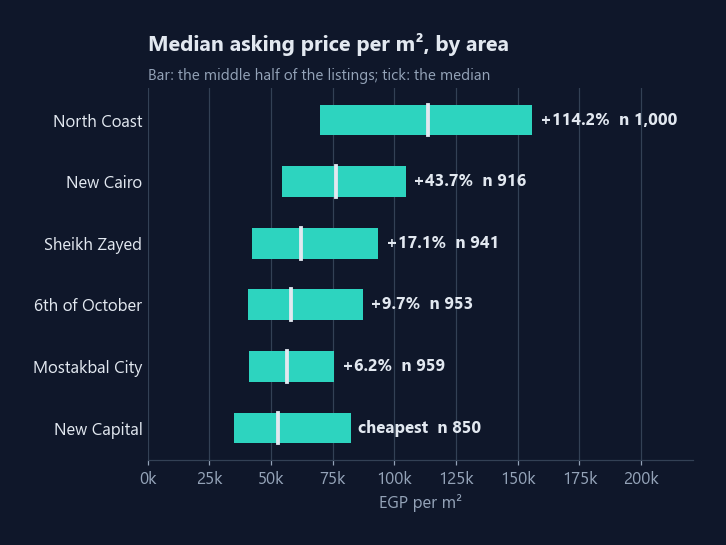

In [19]:
area_rank, area_small = medians(pooled, "area")
area_rank = area_rank.sort_values(["median", "area"], ascending=[False, True], ignore_index=True)
same = area_rank.set_index("area")["median"].sub(market.set_index("area").median_m2).abs()
assert len(same) == len(market) and (same < 0.006).all(), "insight 1 and section 4 disagree on an area median"
area_rank["iqr"] = area_rank.p75 - area_rank.p25
cheapest_area = area_rank.iloc[-1]
area_rank["premium_pct"] = (area_rank["median"] / cheapest_area["median"] - 1) * 100
dearest_area = area_rank.iloc[0]

insights["1"] = dict(
    title="Area ranking", grain="one row per area, latest run week, pooled over sites and unit types",
    groups=rows(area_rank), groups_skipped=len(area_small), listings_skipped=int(area_small.n.sum()),
    dearest_area=dearest_area.area, dearest_n=int(dearest_area.n), dearest_median_m2=dearest_area["median"],
    cheapest_area=cheapest_area.area, cheapest_n=int(cheapest_area.n), cheapest_median_m2=cheapest_area["median"],
    premium_pct=dearest_area.premium_pct, chart=None,
    sentence=(f"{dearest_area.area} has the highest median asking price per m² ({egp(dearest_area['median'])}, "
              f"n = {dearest_area.n:,}), {pct(dearest_area.premium_pct)}% above {cheapest_area.area}, the lowest "
              f"({egp(cheapest_area['median'])}, n = {cheapest_area.n:,}); {skipped(area_small, 'area')}."),
)

g = area_rank.iloc[::-1].reset_index(drop=True)  # the dearest on top
fig, ax = chart("Median asking price per m², by area", "Bar: the middle half of the listings; tick: the median")
ax.barh(g.area, g.p75 - g.p25, left=g.p25, height=0.5, color=SITE_COLOURS[0])
for i, r in g.iterrows():
    ax.plot([r["median"]] * 2, [i - 0.25, i + 0.25], color=INK, linewidth=2.5)
    premium = "cheapest" if i == 0 else f"+{pct(r.premium_pct)}%"
    ax.text(r.p75 + g.p75.max() * 0.02, i, f"{premium}  n {r.n:,}", va="center", color=INK, fontweight="bold")
ax.set_xlim(0, g.p75.max() * 1.42)
ax.xaxis.set_major_formatter(lambda x, _: f"{x / 1000:,.0f}k")
ax.set_xlabel(f"{CURRENCY} per m²")
bars_look(ax)
insights["1"]["chart"] = save(fig, 1, "area-ranking")
print(insights["1"]["sentence"])
area_rank

### Insight 2. Unit type within each area

Grain: one row per area and unit type, latest run week, pooled over sites. The median asking price
per m² of every type with 10 or more listings in the area (the chalet is a North Coast type), and in
each area the gap between its dearest and its cheapest type, in percent of the cheapest.

The gap between the dearest and the cheapest unit type is widest in North Coast: Duplex at 171,058 EGP per m² (n = 10) against Apartment at 52,667 EGP (n = 72), 224.8% apart; 9 area and type groups under 10 listings skipped (24 listings).


,area,types,cheapest_type,cheapest_n,cheapest_median_m2,dearest_type,dearest_n,dearest_median_m2,gap_pct
0,North Coast,8,Apartment,72,52666.825,Duplex,10,171058.37,224.793397
1,New Capital,7,Duplex,32,36353.620,Villa,161,85600.00,135.464859
2,Sheikh Zayed,7,Apartment,385,50520.830,Studio,37,115000.00,127.628881
3,Mostakbal City,8,Apartment,448,45000.000,Twin House,35,85000.00,88.888889
4,6th of October,8,iVilla,43,41015.630,Studio,47,76403.51,86.279011
5,New Cairo,8,iVilla,18,50531.915,Studio,45,93877.55,85.778730


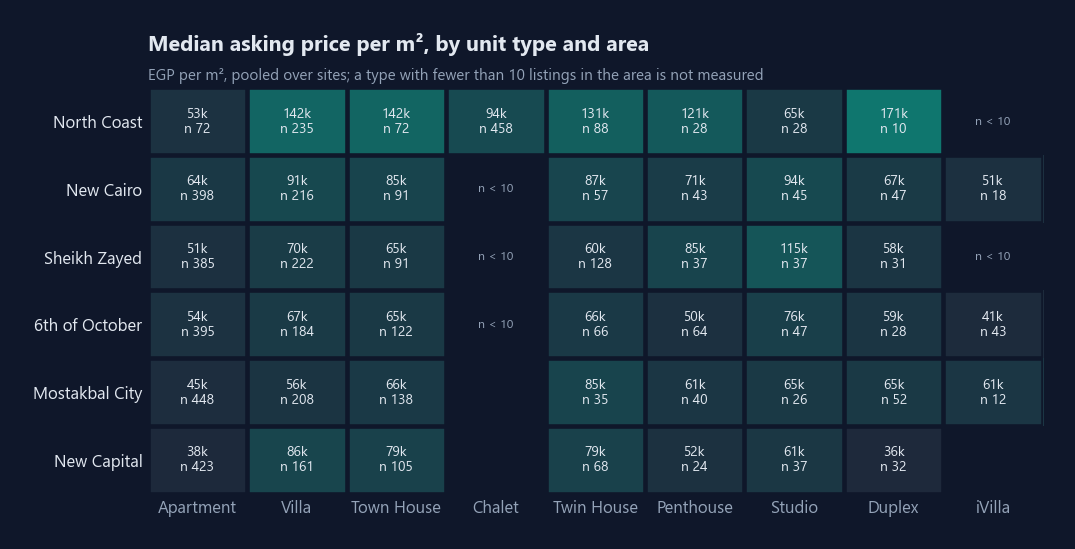

In [20]:
type_area, type_small = medians(pooled, ["area", "unit_type"])
ends = []
for area, g in type_area.groupby("area"):
    g = g.sort_values(["median", "unit_type"], ignore_index=True)
    if len(g) >= 2:
        ends.append(dict(area=area, types=len(g),
                         cheapest_type=g.unit_type.iat[0], cheapest_n=int(g.n.iat[0]), cheapest_median_m2=g["median"].iat[0],
                         dearest_type=g.unit_type.iat[-1], dearest_n=int(g.n.iat[-1]), dearest_median_m2=g["median"].iat[-1],
                         gap_pct=(g["median"].iat[-1] / g["median"].iat[0] - 1) * 100))
type_ends = pd.DataFrame(ends).sort_values(["gap_pct", "area"], ascending=[False, True], ignore_index=True)
widest_types = type_ends.iloc[0]

insights["2"] = dict(
    title="Unit type within each area", grain="one row per area and unit type, latest run week, pooled over sites",
    groups=rows(type_area), groups_skipped=len(type_small), listings_skipped=int(type_small.n.sum()),
    skipped_groups=rows(type_small[["area", "unit_type", "n"]]), by_area=rows(type_ends),
    area=widest_types.area, dearest_type=widest_types.dearest_type, cheapest_type=widest_types.cheapest_type,
    gap_pct=widest_types.gap_pct, chart=None,
    sentence=(f"The gap between the dearest and the cheapest unit type is widest in {widest_types.area}: "
              f"{widest_types.dearest_type} at {egp(widest_types.dearest_median_m2)} per m² (n = {widest_types.dearest_n:,}) "
              f"against {widest_types.cheapest_type} at {egp(widest_types.cheapest_median_m2)} (n = {widest_types.cheapest_n:,}), "
              f"{pct(widest_types.gap_pct)}% apart; {skipped(type_small, 'area and type group')}."),
)

listed = pooled.groupby("unit_type").size()
type_order = sorted(type_area.unit_type.unique(), key=lambda t: (-listed[t], t))  # the most listed type first
fig, ax = plt.subplots(figsize=(10.5, 4.8))
heatmap(ax, type_area, type_small, "area", "unit_type", area_rank.area, type_order)
ax.set_title("Median asking price per m², by unit type and area", pad=24)
ax.text(0, 1.02, f"{CURRENCY} per m², pooled over sites; a type with fewer than {MIN_N} listings in the area is not measured",
        transform=ax.transAxes, color=MUTED, fontsize=10)
insights["2"]["chart"] = save(fig, 2, "type-by-area")
print(insights["2"]["sentence"])
type_ends

### Insight 3. Developer premium

Grain: one row per developer as the sites write it (not `Unknown`), latest run week, pooled over
sites. Each listing's price per m² is set against the pooled median of its own area (all types, the
median of insight 1) as an index, 100 = the area median; a developer's index is the median of its
listings' indices, so a developer selling in two areas is measured against each. Only developers
with 10 or more listings. Of the six sites, only realestate.eg, Nawy and Aqarmap name a developer.

Of 48 developers with 10 or more listings, ADD Properties has the highest index, 219 (n = 12), and Amer Group the lowest, 62 (n = 16), where 100 is the median asking price per m² of the listing's area; developers are named on Aqarmap, Nawy and realestate.eg only, and 259 developers under 10 listings skipped (1,002 listings).


,developer,n,p25,median,p75
0,ADD Properties,12,194.975340,218.649891,239.424257
1,Founders Development,13,144.466670,207.547170,207.547170
2,Marakez,15,184.118012,198.846210,218.316480
3,Sodic,20,132.782399,194.774225,212.959433
4,Hyde Park,26,162.298911,192.828076,235.141900
43,Modon Developments,13,85.986164,85.986164,140.444074
44,IGI,20,75.871797,84.975827,92.633772
45,Arab Developers Holding,18,79.913040,79.913040,90.368776
46,Land Mark Sabbour (LMD),12,78.800002,79.913040,79.913040
47,Amer Group,16,55.402075,61.671513,123.082241


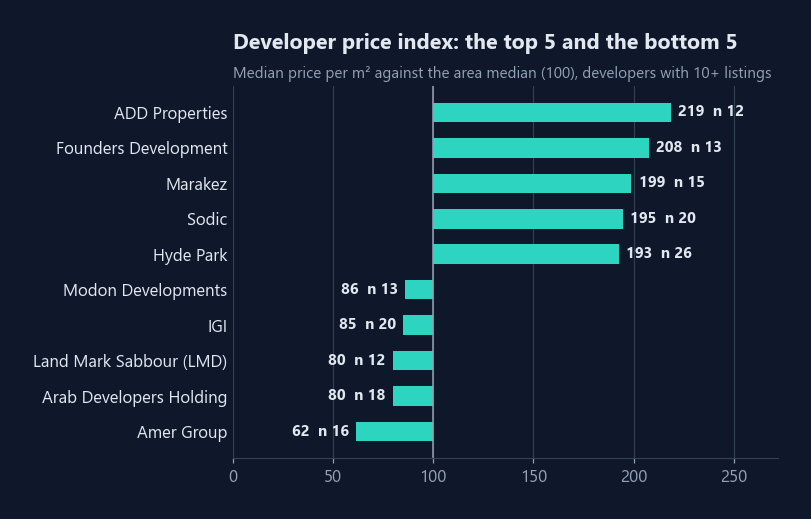

In [21]:
area_median = pooled.groupby("area").price_per_m2.median()
named_dev = pooled[pooled.developer != "Unknown"].assign(index=lambda d: d.price_per_m2 / d.area.map(area_median) * 100)
dev, dev_small = medians(named_dev, "developer", value="index")
dev = dev.sort_values(["median", "developer"], ascending=[False, True], ignore_index=True)
dev_sites = sorted(named_dev.site.unique())
top_dev, bottom_dev = dev.head(5), dev.tail(5)

insights["3"] = dict(
    title="Developer premium", grain="one row per developer, latest run week, pooled over sites; index 100 = the area median",
    developers=len(dev), groups_skipped=len(dev_small), listings_skipped=int(dev_small.n.sum()),
    listings_with_developer=len(named_dev), sites_naming_developers=dev_sites,
    top=rows(top_dev), bottom=rows(bottom_dev),
    top_developer=dev.developer.iat[0], top_index=dev["median"].iat[0], top_n=int(dev.n.iat[0]),
    bottom_developer=dev.developer.iat[-1], bottom_index=dev["median"].iat[-1], bottom_n=int(dev.n.iat[-1]), chart=None,
    sentence=(f"Of {len(dev)} developers with {MIN_N} or more listings, {dev.developer.iat[0]} has the highest index, "
              f"{half_up(dev['median'].iat[0], 0)} (n = {dev.n.iat[0]:,}), and {dev.developer.iat[-1]} the lowest, "
              f"{half_up(dev['median'].iat[-1], 0)} (n = {dev.n.iat[-1]:,}), where 100 is the median asking price per m² of "
              f"the listing's area; developers are named on {', '.join(dev_sites[:-1])} and {dev_sites[-1]} only, "
              f"and {skipped(dev_small, 'developer')}."),
)

show = pd.concat([top_dev, bottom_dev]).drop_duplicates("developer").sort_values(["median", "developer"], ignore_index=True)
fig, ax = chart("Developer price index: the top 5 and the bottom 5",
                f"Median price per m² against the area median (100), developers with {MIN_N}+ listings")
ax.barh(range(len(show)), show["median"] - 100, left=100, height=0.55, color=SITE_COLOURS[0])
ax.axvline(100, color=MUTED, linewidth=1)
span = (show["median"] - 100).abs().max()
for i, r in show.iterrows():
    above = r["median"] >= 100
    ax.text(r["median"] + (span * 0.03 if above else -span * 0.03), i, f"{half_up(r['median'], 0)}  n {r.n:,}",
            va="center", ha="left" if above else "right", color=INK, fontweight="bold", fontsize=10)
ax.set_yticks(range(len(show)), [label(d, 30) for d in show.developer])
ax.set_xlim(0, 100 + span * 1.45)  # an index starts at 0
bars_look(ax)
insights["3"]["chart"] = save(fig, 3, "developer-index")
print(insights["3"]["sentence"])
pd.concat([top_dev, bottom_dev])

### Insight 4. Compound ranking

Grain: one row per area and compound name, latest run week, pooled over sites; only named compounds
(not `Unknown`) with 10 or more listings. In each area, the compound with the highest and the lowest
median asking price per m². Compound names are as the sites write them, so one compound can appear
under two spellings and is then counted as two.

Inside one area the spread between the dearest and the cheapest compound with 10 or more listings is widest in North Coast: Dayz at 338,127 EGP per m² (n = 10) against Telal North Coast at 65,509 EGP (n = 10), 416.2% apart; 76 compounds measured, 1,095 compounds under 10 listings skipped (3,067 listings), and the names are as the sites write them.


,area,compounds,cheapest,cheapest_n,cheapest_median_m2,dearest,dearest_n,dearest_median_m2,spread_pct
0,North Coast,9,Telal North Coast,10,65508.795,Dayz,10,338127.305,416.155586
1,New Cairo,16,Mountain View iCity,18,36853.260,Mivida Compound,11,102500.000,178.130076
2,Sheikh Zayed,15,Park Valley Compound,17,36082.470,The Hillage,11,114941.180,218.551308
3,6th of October,17,9th District,11,19000.000,New Giza,10,82412.175,333.748289
4,Mostakbal City,11,L’Avenir,16,31273.855,At East Compound,11,102631.580,228.170544
5,New Capital,8,Al Maqsad,53,30344.830,La Vista City,109,84836.070,179.573390


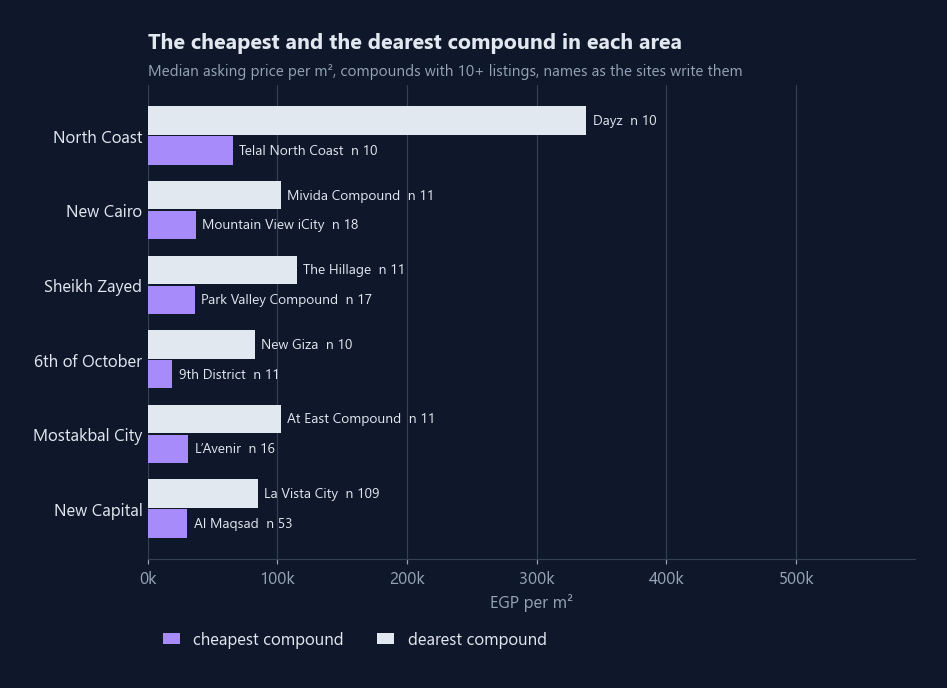

In [22]:
named_cpd = pooled[pooled.compound != "Unknown"]
cpd, cpd_small = medians(named_cpd, ["area", "compound"])
ends = []
for area, g in cpd.groupby("area"):
    g = g.sort_values(["median", "compound"], ignore_index=True)
    ends.append(dict(area=area, compounds=len(g),
                     cheapest=g.compound.iat[0], cheapest_n=int(g.n.iat[0]), cheapest_median_m2=g["median"].iat[0],
                     dearest=g.compound.iat[-1], dearest_n=int(g.n.iat[-1]), dearest_median_m2=g["median"].iat[-1],
                     spread_pct=(g["median"].iat[-1] / g["median"].iat[0] - 1) * 100))
cpd_ends = (pd.DataFrame(ends).set_index("area").reindex(area_rank.area).dropna(how="all").reset_index()
            .astype({"compounds": int, "cheapest_n": int, "dearest_n": int}))
widest_cpd = cpd_ends.sort_values(["spread_pct", "area"], ascending=[False, True]).iloc[0]

insights["4"] = dict(
    title="Compound ranking", grain="one row per area and compound name as the sites write it, latest run week, pooled over sites",
    compounds=len(cpd), groups_skipped=len(cpd_small), listings_skipped=int(cpd_small.n.sum()),
    listings_without_compound=int((pooled.compound == "Unknown").sum()), by_area=rows(cpd_ends),
    widest_area=widest_cpd.area, widest_spread_pct=widest_cpd.spread_pct, chart=None,
    sentence=(f"Inside one area the spread between the dearest and the cheapest compound with {MIN_N} or more listings "
              f"is widest in {widest_cpd.area}: {label(widest_cpd.dearest, 99)} at {egp(widest_cpd.dearest_median_m2)} per m² "
              f"(n = {widest_cpd.dearest_n:,}) against {label(widest_cpd.cheapest, 99)} at {egp(widest_cpd.cheapest_median_m2)} "
              f"(n = {widest_cpd.cheapest_n:,}), {pct(widest_cpd.spread_pct)}% apart; {len(cpd):,} compounds measured, "
              f"{skipped(cpd_small, 'compound')}, and the names are as the sites write them."),
)

g = cpd_ends.iloc[::-1].reset_index(drop=True)
fig, ax = chart("The cheapest and the dearest compound in each area",
                f"Median asking price per m², compounds with {MIN_N}+ listings, names as the sites write them", size=(9, 5.6))
y = np.arange(len(g))
ax.barh(y - 0.2, g.cheapest_median_m2, height=0.38, color=SITE_COLOURS[2], label="cheapest compound")
ax.barh(y + 0.2, g.dearest_median_m2, height=0.38, color=SITE_COLOURS[1], label="dearest compound")
top = g.dearest_median_m2.max()
for i, r in g.iterrows():
    for offset, name, value, n in ((-0.2, r.cheapest, r.cheapest_median_m2, r.cheapest_n), (0.2, r.dearest, r.dearest_median_m2, r.dearest_n)):
        ax.text(value + top * 0.015, i + offset, f"{label(name)}  n {n:,}", va="center", color=INK, fontsize=9)
ax.set_yticks(y, g.area)
ax.set_xlim(0, top * 1.75)
ax.xaxis.set_major_formatter(lambda x, _: f"{x / 1000:,.0f}k")
ax.set_xlabel(f"{CURRENCY} per m²")
bars_look(ax)
ax.legend(ncol=2, frameon=False, loc="upper left", bbox_to_anchor=(0, -0.12), handlelength=1, labelcolor=INK)
insights["4"]["chart"] = save(fig, 4, "compounds")
print(insights["4"]["sentence"])
cpd_ends

### Insight 5. Size and bedrooms

Grain of the first table: one row per unit type and size band, latest run week, pooled over sites.
The bands are under 100, 100 to 150, 150 to 200, 200 to 300, and 300 m² and over; each includes its
lower bound. Grain of the second: one row per bedroom count, the median asking price per bedroom
(asking price over bedrooms). Rows with no bedroom count, or 0 bedrooms, are left out of the second
and counted. Bigger and smaller units are different listings side by side, so the direction below
describes them and does not measure what adding space does to a price.

In 7 of 9 unit types with two or more size bands, the largest band's median asking price per m² is below the smallest band's; the median asking price per bedroom is 5,235,000 EGP at 1 bedroom (n = 385) and 3,477,800 EGP at 10 bedrooms (n = 14). These are different listings side by side, not the effect of size; 14 type and band groups under 10 listings skipped (38 listings), 4 bedroom counts under 10 listings skipped (10 listings), and 138 listings without a bedroom count and 12 with 0 bedrooms are left out of the bedroom figures.


,unit_type,bands,smallest_band,smallest_median_m2,largest_band,largest_median_m2,change_pct
0,Apartment,5,under 100,63330.420,300 and over,40000.000,-36.839200
1,Chalet,4,under 100,94628.695,200 to 300,95097.560,0.495479
2,Duplex,4,100 to 150,83000.000,300 and over,42050.440,-49.336819
3,Penthouse,4,100 to 150,72483.495,300 and over,34135.570,-52.905734
4,Studio,2,under 100,76403.510,100 to 150,65067.370,-14.837198
5,Town House,4,100 to 150,75579.435,300 and over,67916.670,-10.138691
6,Twin House,3,150 to 200,103219.015,300 and over,70000.000,-32.183038
7,Villa,4,100 to 150,85000.000,300 and over,80000.000,-5.882353
8,iVilla,2,150 to 200,40452.260,200 to 300,47544.645,17.532729


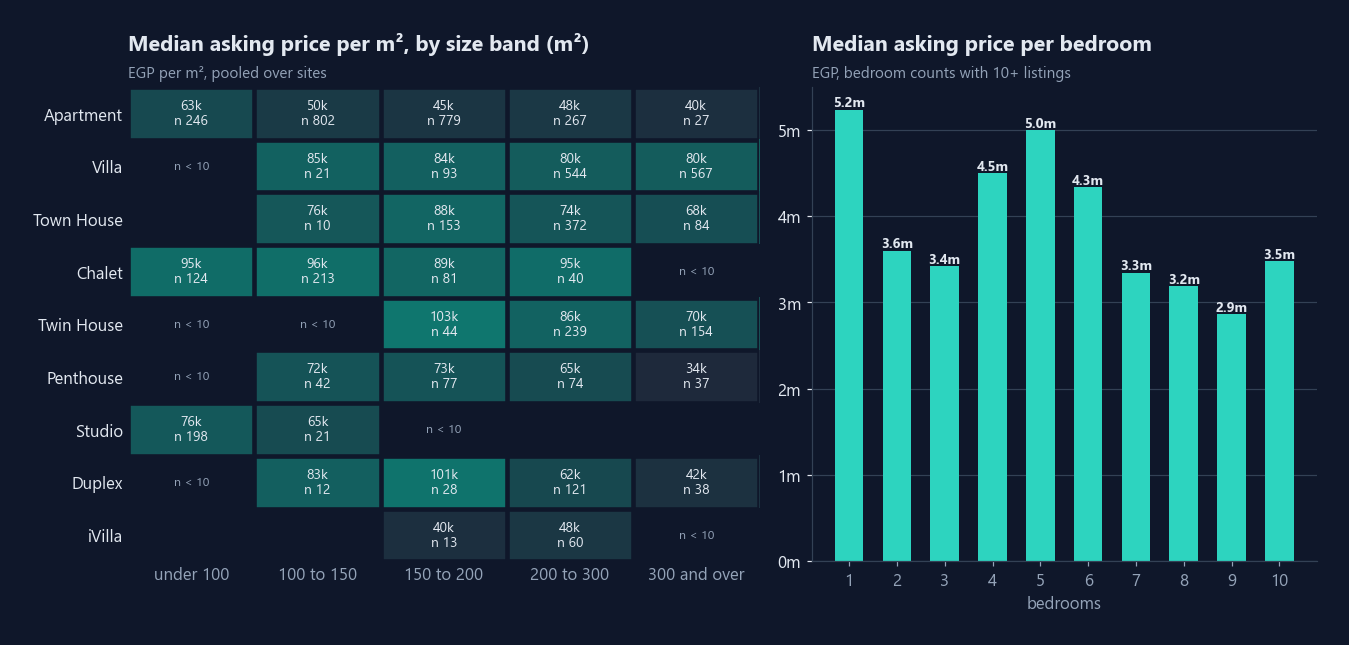

In [23]:
BANDS = [0, 100, 150, 200, 300, float("inf")]
BAND_NAMES = ["under 100", "100 to 150", "150 to 200", "200 to 300", "300 and over"]
sized = pooled.assign(band=pd.cut(pooled.size_m2, BANDS, right=False, labels=BAND_NAMES))
size_type, size_small = medians(sized, ["unit_type", "band"])
size_type["band"] = size_type.band.astype(str)
size_small["band"] = size_small.band.astype(str)

trend = []
for unit_type, g in size_type.groupby("unit_type"):
    g = g.assign(order=g.band.map(BAND_NAMES.index)).sort_values("order", ignore_index=True)
    if len(g) >= 2:
        trend.append(dict(unit_type=unit_type, bands=len(g), smallest_band=g.band.iat[0], smallest_median_m2=g["median"].iat[0],
                          largest_band=g.band.iat[-1], largest_median_m2=g["median"].iat[-1],
                          change_pct=(g["median"].iat[-1] / g["median"].iat[0] - 1) * 100))
size_trend = pd.DataFrame(trend)
lower = int((size_trend.change_pct < 0).sum())

no_bedrooms, zero_bedrooms = int(pooled.bedrooms.isna().sum()), int((pooled.bedrooms == 0).sum())
with_beds = pooled[pooled.bedrooms > 0].assign(price_per_bedroom=lambda d: d.asking_price / d.bedrooms)
beds, beds_small = medians(with_beds, "bedrooms", value="price_per_bedroom")
beds["bedrooms"], beds_small["bedrooms"] = beds.bedrooms.astype(int), beds_small.bedrooms.astype(int)
(first_beds, first_n, first_median), (last_beds, last_n, last_median) = (
    (int(beds.bedrooms.iat[i]), int(beds.n.iat[i]), beds["median"].iat[i]) for i in (0, -1))

insights["5"] = dict(
    title="Size and bedrooms",
    grain="one row per unit type and size band; one row per bedroom count; latest run week, pooled over sites",
    size_groups=rows(size_type), size_groups_skipped=len(size_small), size_listings_skipped=int(size_small.n.sum()),
    by_type=rows(size_trend), types_compared=len(size_trend), types_lower_in_largest_band=lower,
    bedroom_groups=rows(beds), bedroom_groups_skipped=len(beds_small), bedroom_listings_skipped=int(beds_small.n.sum()),
    listings_without_bedrooms=no_bedrooms, listings_with_0_bedrooms=zero_bedrooms, chart=None,
    sentence=(f"In {lower} of {len(size_trend)} unit types with two or more size bands, the largest band's median asking "
              f"price per m² is below the smallest band's; the median asking price per bedroom is {egp(first_median)} "
              f"at {first_beds} bedroom{'' if first_beds == 1 else 's'} (n = {first_n:,}) and "
              f"{egp(last_median)} at {last_beds} bedrooms (n = {last_n:,}). "
              f"These are different listings side by side, not the effect of size; {skipped(size_small, 'type and band group')}, "
              f"{skipped(beds_small, 'bedroom count')}, and {no_bedrooms} listings without a bedroom count and "
              f"{zero_bedrooms} with 0 bedrooms are left out of the bedroom figures."),
)

fig, (left, right) = plt.subplots(1, 2, figsize=(12, 5.6), gridspec_kw={"width_ratios": [1.25, 1]})
size_order = sorted(size_type.unit_type.unique(), key=lambda t: (-listed[t], t))  # types with a measured band
heatmap(left, size_type, size_small, "unit_type", "band", size_order, BAND_NAMES)
left.set_title("Median asking price per m², by size band (m²)", pad=24)
left.text(0, 1.02, f"{CURRENCY} per m², pooled over sites", transform=left.transAxes, color=MUTED, fontsize=10)
right.bar(beds.bedrooms, beds["median"], width=0.6, color=SITE_COLOURS[0])
for r in beds.itertuples():
    right.text(r.bedrooms, r.median, f"{r.median / 1e6:,.1f}m", ha="center", va="bottom", color=INK, fontsize=9, fontweight="bold")
right.set_xticks(beds.bedrooms)
right.yaxis.set_major_formatter(lambda v, _: f"{v / 1e6:,.0f}m")
right.yaxis.grid(True, color=GRID, linewidth=0.8)
right.set_axisbelow(True)
right.set_xlabel("bedrooms")
right.set_title("Median asking price per bedroom", pad=24)
right.text(0, 1.02, f"{CURRENCY}, bedroom counts with {MIN_N}+ listings", transform=right.transAxes, color=MUTED, fontsize=10)
fig.tight_layout()
insights["5"]["chart"] = save(fig, 5, "size-and-bedrooms")
print(insights["5"]["sentence"])
size_trend

### Insight 6. Site differences

Grain of the first table: one row per area and site, latest run week, each site's own rows (not
pooled: a site is compared as it is). Nawy is set against Dubizzle Egypt in every area where both
have 10 or more listings. Nawy shows mostly developers' launch prices and Dubizzle is a resale
marketplace; that difference in kind is the likely reason for a gap, not a proven one. Aqarmap marks
paid placements ("sponsored") in its page data; gold does not keep the flag, so it is read here from
the saved pages the run used (`silver.run_log.pages_used`, under `data/raw/aqarmap/<run week>/`):
grain one row per Aqarmap listing of the latest run week. Only each listing's id and flag are read.
Aqarmap is read by hand in a browser before the run, so a week without Aqarmap rows (a fresh clone)
skips the sponsored share with a note and writes null for its keys.

Nawy's median asking price per m² is above Dubizzle's in 6 of 6 areas compared (from +14.0% to +83.9%); Nawy shows mostly developers' launch prices and Dubizzle is a resale marketplace, the likely reason, not a proven one. 116 of Aqarmap's 721 rows (16.1%) are sponsored placements, read from its saved pages because gold does not keep the flag, so Aqarmap's numbers lean towards paid listings; no area and site group skipped.


listing_id
not_featured               581
sold_by_owner                3
sold_by_owner_sponsored      1
sponsored                  116
spotlight                   20
Name: count, dtype: int64

source,nawy,dubizzle,nawy_over_dubizzle_pct
area,,,
North Coast,156911.525,95703.705,63.955539
New Cairo,93894.770,70731.710,32.747773
Sheikh Zayed,93750.000,50990.195,83.858877
6th of October,93546.650,51470.590,81.747771
Mostakbal City,75763.250,43566.535,73.902400
New Capital,56345.485,49423.055,14.006479


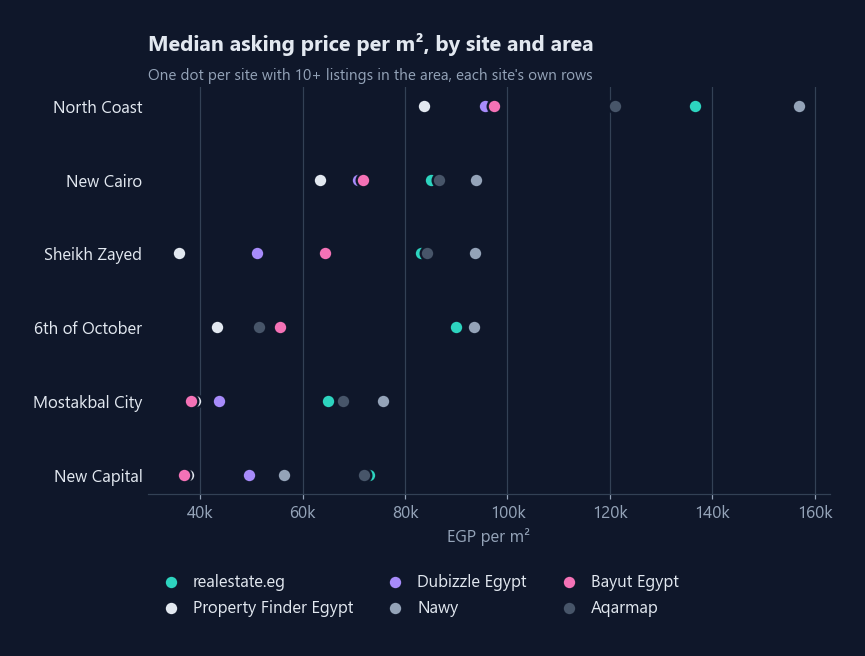

In [24]:
site_area, site_small = medians(facts, ["area", "source", "site"])
wide = site_area.pivot(index="area", columns="source", values="median").reindex(columns=["nawy", "dubizzle"])
both = wide.dropna().reindex([a for a in area_rank.area if a in wide.dropna().index])
nawy_gap = (both.nawy / both.dubizzle - 1) * 100
nawy_above = int((nawy_gap > 0).sum())

aqarmap = dict(aqarmap_pages_read=None, aqarmap_rows=None, aqarmap_flags=None, aqarmap_sponsored=None,
               aqarmap_sponsored_pct=None)
sponsored_clause = ""
flag_counts = None
if facts.source.eq("aqarmap").any():
    pages = query("SELECT unnest(pages_used) AS page FROM silver.run_log WHERE source = 'aqarmap' AND run_week = %s ORDER BY 1",
                  latest_week).page
    assert len(pages) > 0, "no Aqarmap page in silver.run_log for the latest run week"
    flags = {}
    for page in pages:
        payload, decoder = flight(gzip.open(ROOT / "data" / "raw" / "aqarmap" / latest_week.isoformat() / page, "rt",
                                            encoding="utf-8").read()), json.JSONDecoder()
        for found in re.finditer(r'"listing":\s*\{', payload):  # the parser's rule: the card copy with attributes
            listing = decoder.raw_decode(payload, found.end() - 1)[0]
            if "attributes" in listing:
                flags.setdefault(str(listing["id"]), listing.get("featuredType"))
    aqarmap_flag = facts.loc[facts.source == "aqarmap", "listing_id"].map(flags)
    flag_counts = aqarmap_flag.fillna("no flag found").value_counts().sort_index()
    sponsored = int((aqarmap_flag == "sponsored").sum())
    sponsored_pct = sponsored / len(aqarmap_flag) * 100
    aqarmap = dict(aqarmap_pages_read=len(pages), aqarmap_rows=len(aqarmap_flag),
                   aqarmap_flags={k: int(v) for k, v in flag_counts.items()}, aqarmap_sponsored=sponsored,
                   aqarmap_sponsored_pct=sponsored_pct)
    sponsored_clause = (f"{sponsored:,} of Aqarmap's {len(aqarmap_flag):,} rows ({pct(sponsored_pct)}%) are sponsored "
                        f"placements, read from its saved pages because gold does not keep the flag, so Aqarmap's numbers "
                        f"lean towards paid listings; ")
else:
    print("No Aqarmap rows in the latest run week (it is read by hand in a browser): the sponsored share is skipped "
          "and its keys are null.")

tail = sponsored_clause + skipped(site_small, "area and site group")  # a sentence of its own: capitalised
insights["6"] = dict(
    title="Site differences", grain="one row per area and site, latest run week, each site's own rows",
    groups=rows(site_area), groups_skipped=len(site_small), listings_skipped=int(site_small.n.sum()),
    skipped_groups=rows(site_small[["area", "site", "n"]]),
    nawy_vs_dubizzle=[dict(area=a, nawy_median_m2=plain(both.nawy[a]), dubizzle_median_m2=plain(both.dubizzle[a]),
                           nawy_over_dubizzle_pct=plain(nawy_gap[a])) for a in both.index],
    areas_compared=len(both), nawy_above_areas=nawy_above,
    nawy_gap_min_pct=plain(nawy_gap.min()), nawy_gap_max_pct=plain(nawy_gap.max()),
    **aqarmap, chart=None,
    sentence=(f"Nawy's median asking price per m² is above Dubizzle's in {nawy_above} of {len(both)} areas compared "
              f"(from {pct(nawy_gap.min(), signed=True)}% to {pct(nawy_gap.max(), signed=True)}%); Nawy shows mostly developers' "
              f"launch prices and Dubizzle is a resale marketplace, the likely reason, not a proven one. "
              f"{tail[0].upper()}{tail[1:]}."),
)

order = list(area_rank.area[::-1])  # the dearest area on top
fig, ax = chart("Median asking price per m², by site and area",
                f"One dot per site with {MIN_N}+ listings in the area, each site's own rows", size=(8, 4.8))
for colour, source, name in zip(SITE_COLOURS, sites.source, sites.name):
    d = site_area[site_area.source == source].set_index("area").reindex(order)
    ax.scatter(d["median"], range(len(order)), s=80, color=colour, edgecolors=SURFACE, linewidths=1.5, label=name, zorder=3)
ax.set_yticks(range(len(order)), order)
ax.xaxis.set_major_formatter(lambda x, _: f"{x / 1000:,.0f}k")
ax.set_xlabel(f"{CURRENCY} per m²")
bars_look(ax)
ax.legend(ncol=3, frameon=False, loc="upper left", bbox_to_anchor=(0, -0.16), handlelength=1, labelcolor=INK)
insights["6"]["chart"] = save(fig, 6, "site-differences")
print(insights["6"]["sentence"])
if flag_counts is not None:
    display(flag_counts)
both.assign(nawy_over_dubizzle_pct=nawy_gap)

### Insight 7. Cross-site duplicates, estimated

Grain: one row per pooled listing with a named compound, latest run week. A listing has a likely
twin when a listing on another site is in the same area and compound (names compared without
regard to case), of the same type, within 2 m² in size and within 2% in asking price (the
difference at most 2% of the lower price). This is an estimate: the sites spell compounds
differently, which hides twins, and two different units can match, which adds some. The Bayut Egypt
rows that copy a Dubizzle ad (the same listing id) are exact copies, reported apart and already
left out of the pooled rows. Bayut is read by hand in a browser before the run, so a week without
Bayut rows (a fresh clone) skips that clause with a note and writes null for its two keys.

An estimated 1.7% of the 4,965 pooled listings with a named compound (84 listings) match a listing on another site in the same area and compound, of the same type, within 2 m² and 2% of price; it is an estimate, as the sites spell compounds differently and two units can match by chance. Apart from these, 138 of Bayut Egypt's 143 rows are exact copies of Dubizzle ads (the same listing id) and are left out of every pooled number.


,source,site,n,twins,twin_pct
0,realestate,realestate.eg,757,0,0.000000
1,propertyfinder,Property Finder Egypt,773,33,4.269082
2,dubizzle,Dubizzle Egypt,2116,42,1.984877
3,nawy,Nawy,850,7,0.823529
4,bayut,Bayut Egypt,5,0,0.000000
5,aqarmap,Aqarmap,464,2,0.431034


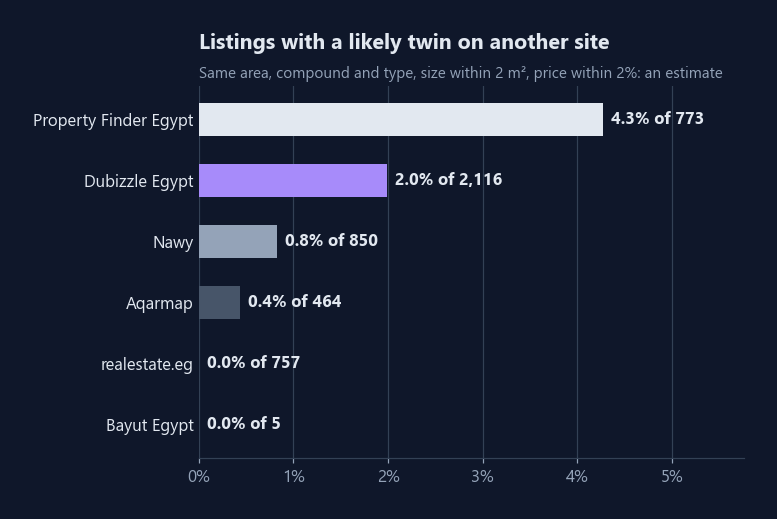

In [25]:
cand = pooled[pooled.compound != "Unknown"].assign(key=lambda d: d.compound.str.casefold())
pairs = cand.merge(cand, on=["area_id", "key", "unit_type"], suffixes=("", "_other"))
pairs = pairs[(pairs.source != pairs.source_other)
              & ((pairs.size_m2 - pairs.size_m2_other).abs() <= 2)
              & ((pairs.asking_price - pairs.asking_price_other).abs()
                 <= 0.02 * pairs[["asking_price", "asking_price_other"]].min(axis=1))]
twins = set(zip(pairs.source, pairs.listing_id))
cand["twin"] = [key in twins for key in zip(cand.source, cand.listing_id)]
by_site_twin = (cand.groupby(["source", "site"], sort=False).twin.agg(n="size", twins="sum").reset_index()
                .assign(twin_pct=lambda d: d.twins / d.n * 100))
pair_counts = (pairs[pairs.source < pairs.source_other].groupby(["site", "site_other"]).size()
               .rename("pairs").reset_index().sort_values(["pairs", "site", "site_other"], ascending=[False, True, True]))
bayut_rows = int(facts.source.eq("bayut").sum()) or None
bayut_clause = (f" Apart from these, {int(mirror.sum())} of Bayut Egypt's {bayut_rows} rows are exact copies of Dubizzle "
                f"ads (the same listing id) and are left out of every pooled number.") if bayut_rows else ""
if not bayut_rows:
    print("No Bayut rows in the latest run week (it is read by hand in a browser): the exact-copy count is skipped "
          "and its keys are null.")
twin_share = cand.twin.mean() * 100

insights["7"] = dict(
    title="Cross-site duplicates, estimated", grain="one row per pooled listing with a named compound, latest run week",
    estimate=True, listings_checked=len(cand), listings_without_compound=int((pooled.compound == "Unknown").sum()),
    listings_with_twin=int(cand.twin.sum()), twin_share_pct=twin_share,
    twin_share_of_all_pooled_pct=cand.twin.sum() / len(pooled) * 100,
    by_site=rows(by_site_twin), site_pairs=rows(pair_counts),
    bayut_rows=bayut_rows, bayut_exact_copies_of_dubizzle=int(mirror.sum()) if bayut_rows else None, chart=None,
    sentence=(f"An estimated {pct(twin_share)}% of the {len(cand):,} pooled listings with a named compound "
              f"({int(cand.twin.sum()):,} listings) match a listing on another site in the same area and compound, of the "
              f"same type, within 2 m² and 2% of price; it is an estimate, as the sites spell compounds differently and two "
              f"units can match by chance.{bayut_clause}"),
)

g = by_site_twin.sort_values(["twin_pct", "site"], ignore_index=True)
colour_of = dict(zip(sites.source, SITE_COLOURS))
fig, ax = chart("Listings with a likely twin on another site",
                "Same area, compound and type, size within 2 m², price within 2%: an estimate")
ax.barh(g.site, g.twin_pct, height=0.55, color=[colour_of[s] for s in g.source])
for i, r in g.iterrows():
    ax.text(r.twin_pct + g.twin_pct.max() * 0.02, i, f"{pct(r.twin_pct)}% of {r.n:,}", va="center", color=INK, fontweight="bold")
ax.set_xlim(0, g.twin_pct.max() * 1.35)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:,.0f}%")
bars_look(ax)
insights["7"]["chart"] = save(fig, 7, "cross-site-duplicates")
print(insights["7"]["sentence"])
by_site_twin

### Insight 8. Our units

Grain: one row per unit of ours (generated, see the note before section 5). Each unit against the
pooled median of its compound over every type, when the compound has 10 or more listings in the
latest run week, else "no compound median"; the ten units furthest above the median of their type in
their area (`gold.unit_gap`); and the share of competing listings cheaper per m² than our median unit
by area and by type, as defined and counted in section 6.

18 of our 60 generated units sit in a compound with 10 or more listings: 12 ask more per m² than the compound's median over all types and 6 ask the same or less; the other 42 have no compound median. NC-VIL-02 is furthest above the median of its type in its area, at +15.0%. The share of competing listings cheaper per m² than our median unit runs from 46.9% in Mostakbal City to 52.9% in New Capital, and from 47.9% for Duplex to 59.1% for Penthouse.


,unit_code,area_id,area,unit_type,price_per_m2,median_price_per_m2,gap_pct,listings_compared,listings_cheaper,compound,compound_n,compound_median_m2,compound_gap_pct,compound_note
0,CAP-APT-01,new-administrative-capital,New Capital,Apartment,33300.00,38122.64,-12.65,423,156,New Garden City,54,38108.940,-12.618929,
1,CAP-APT-02,new-administrative-capital,New Capital,Apartment,38818.18,38122.64,1.82,423,214,Green Avenue,4,30814.285,NaN,no compound median
2,CAP-APT-03,new-administrative-capital,New Capital,Apartment,37655.17,38122.64,-1.23,423,205,EL Captain New Capital Compound,3,73000.000,NaN,no compound median
3,CAP-APT-04,new-administrative-capital,New Capital,Apartment,35947.37,38122.64,-5.71,423,184,Stau,5,22857.140,NaN,no compound median
4,CAP-DUP-01,new-administrative-capital,New Capital,Duplex,35921.57,36353.62,-1.19,32,16,Hava,5,25490.200,NaN,no compound median
5,CAP-PH-01,new-administrative-capital,New Capital,Penthouse,57904.76,51822.65,11.74,24,18,Armonia,5,49119.500,NaN,no compound median
6,CAP-TH-01,new-administrative-capital,New Capital,Town House,87176.47,78530.61,11.01,105,65,Vinci,13,50000.000,74.352940,
7,CAP-TW-01,new-administrative-capital,New Capital,Twin House,85700.00,78571.43,9.07,68,39,La Vista City,109,84836.070,1.018352,
8,CAP-VIL-01,new-administrative-capital,New Capital,Villa,96296.30,85600.00,12.50,161,106,Noor City,53,55160.140,74.575880,
9,CAP-VIL-02,new-administrative-capital,New Capital,Villa,87243.90,85600.00,1.92,161,89,Granville,17,78530.610,11.095406,


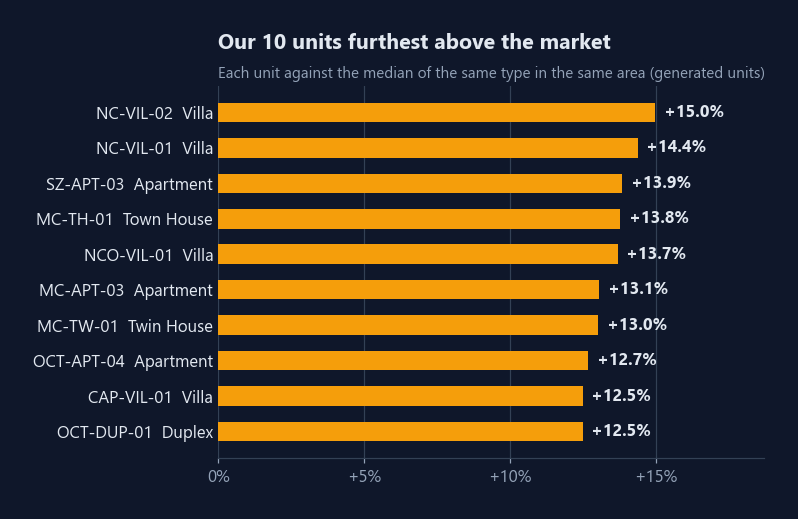

In [26]:
compound_of = query("SELECT u.unit_code, c.compound FROM gold.fact_our_unit u JOIN gold.dim_compound c USING (compound_key)")
compound_median = (named_cpd.groupby(["area_id", "compound"]).price_per_m2
                   .agg(compound_n="size", compound_median_m2="median").reset_index())
ours = (units.merge(compound_of, on="unit_code").merge(compound_median, how="left", on=["area_id", "compound"])
        .sort_values("unit_code", ignore_index=True))
ours["compound_n"] = ours.compound_n.fillna(0).astype(int)
measured = ours.compound_n >= MIN_N
ours["compound_gap_pct"] = ((ours.price_per_m2 / ours.compound_median_m2 - 1) * 100).where(measured)
ours["compound_note"] = np.where(measured, "", "no compound median")
top_units = ours.dropna(subset=["gap_pct"]).sort_values(["gap_pct", "unit_code"], ascending=[False, True]).head(10)
cheaper_area = by_area.rename(index=area_name).sort_values(["cheaper_pct"]).cheaper_pct
cheaper_type = by_type.sort_values(["cheaper_pct"]).cheaper_pct

insights["8"] = dict(
    title="Our units", grain="one row per unit of ours (generated units), latest run week",
    units=len(ours), units_with_compound_median=int(measured.sum()), units_without_compound_median=int((~measured).sum()),
    units_above_compound_median=int((ours.compound_gap_pct > 0).sum()),
    units_at_or_below_compound_median=int((ours.compound_gap_pct <= 0).sum()),
    by_unit=rows(ours[["unit_code", "area", "unit_type", "compound", "compound_n", "compound_gap_pct", "compound_note", "gap_pct"]]),
    top_units=rows(top_units[["unit_code", "area", "unit_type", "gap_pct", "listings_compared"]]),
    top_unit=top_units.unit_code.iat[0], top_gap_pct=top_units.gap_pct.iat[0],
    share_cheaper_by_area=rows(by_area.rename(index=area_name).reset_index(names="area")),
    share_cheaper_by_type=rows(by_type.reset_index()), chart=None,
    sentence=(f"{int(measured.sum())} of our {len(ours)} generated units sit in a compound with {MIN_N} or more listings: "
              f"{int((ours.compound_gap_pct > 0).sum())} ask more per m² than the compound's median over all types and "
              f"{int((ours.compound_gap_pct <= 0).sum())} ask the same or less; the other {int((~measured).sum())} have no "
              f"compound median. {top_units.unit_code.iat[0]} is furthest above the median of its type in its area, at "
              f"{pct(top_units.gap_pct.iat[0], signed=True)}%. The share of competing listings cheaper per m² than our median "
              f"unit runs from {pct(cheaper_area.iat[0])}% in {cheaper_area.index[0]} to {pct(cheaper_area.iat[-1])}% in "
              f"{cheaper_area.index[-1]}, and from {pct(cheaper_type.iat[0])}% for {cheaper_type.index[0]} to "
              f"{pct(cheaper_type.iat[-1])}% for {cheaper_type.index[-1]}."),
)

g = top_units.iloc[::-1].reset_index(drop=True)
fig, ax = chart("Our 10 units furthest above the market",
                "Each unit against the median of the same type in the same area (generated units)")
ax.barh([f"{r.unit_code}  {r.unit_type}" for r in g.itertuples()], g.gap_pct, height=0.55, color=OURS)
for i, r in g.iterrows():
    ax.text(r.gap_pct + g.gap_pct.max() * 0.02, i, f"{pct(r.gap_pct, signed=True)}%", va="center", color=INK, fontweight="bold")
ax.set_xlim(0, g.gap_pct.max() * 1.25)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
ax.xaxis.set_major_formatter(lambda x, _: f"{x:+.0f}%" if x else "0%")
bars_look(ax)
insights["8"]["chart"] = save(fig, 8, "our-units")
print(insights["8"]["sentence"])
ours

### Insight 9. Week over week

Grain: one row per site and listing in the last two run weeks (`gold.fact_listing_price`). Price cuts
and rises are the listings of `gold.price_change` whose previous run week is the week before; new
listings are in the latest week and not the one before, dropped listings the other way round. With
one run week there is nothing to compare: the cell says so, writes nulls and draws no chart.

In [27]:
weeks = query("SELECT week_key FROM gold.dim_week ORDER BY week_key DESC LIMIT 2").week_key.tolist()
week_moves = dict(latest_week=latest_week.isoformat(), previous_week=None, price_cuts=None, price_rises=None,
                  new_listings=None, dropped_listings=None)
if len(weeks) < 2:
    print("needs two run weeks")
    sentence = f"Week over week needs two run weeks; the warehouse has one, {latest_week.day} {latest_week:%B %Y}."
else:
    previous = weeks[1]
    changed = query("SELECT count(*) FILTER (WHERE is_cut) AS cuts, count(*) FILTER (WHERE NOT is_cut) AS rises"
                    " FROM gold.price_change WHERE week_key = %s AND old_week_key = %s", latest_week, previous).iloc[0]
    moved = query("""
        SELECT count(*) FILTER (WHERE p.listing_id IS NULL) AS new_listings, count(*) FILTER (WHERE l.listing_id IS NULL) AS dropped
        FROM (SELECT site_key, listing_id FROM gold.fact_listing_price WHERE week_key = %s) l
        FULL JOIN (SELECT site_key, listing_id FROM gold.fact_listing_price WHERE week_key = %s) p USING (site_key, listing_id)
    """, latest_week, previous).iloc[0]
    week_moves.update(previous_week=previous.isoformat(), price_cuts=int(changed.cuts), price_rises=int(changed.rises),
                      new_listings=int(moved.new_listings), dropped_listings=int(moved.dropped))
    sentence = (f"Between the run weeks of {previous.day} {previous:%B %Y} and {latest_week.day} {latest_week:%B %Y}, "
                f"{week_moves['price_cuts']:,} listings cut their asking price per m², {week_moves['price_rises']:,} raised it, "
                f"{week_moves['new_listings']:,} listings are new and {week_moves['dropped_listings']:,} are no longer listed.")
insights["9"] = dict(title="Week over week", grain="one row per site and listing in the last two run weeks",
                     **week_moves, chart=None, sentence=sentence)
if week_moves["previous_week"]:
    labels = ["price cuts", "price rises", "new listings", "dropped listings"]
    counts = [week_moves[k] for k in ("price_cuts", "price_rises", "new_listings", "dropped_listings")]
    fig, ax = chart("Week over week", f"Run week of {latest_week.day} {latest_week:%B %Y} against the week before")
    ax.barh(labels[::-1], counts[::-1], height=0.55, color=SITE_COLOURS[0])
    for i, v in enumerate(counts[::-1]):
        ax.text(v + max(counts) * 0.02, i, f"{v:,}", va="center", color=INK, fontweight="bold")
    ax.set_xlim(0, max(10, max(counts)) * 1.2)
    bars_look(ax)
    insights["9"]["chart"] = save(fig, 9, "week-over-week")
print(sentence)

needs two run weeks
Week over week needs two run weeks; the warehouse has one, 4 October 2026.


### Insight 10. Spread of price per m² in each area

Grain: one row per area, latest run week, pooled over sites and unit types. The 10th, 25th, 50th, 75th
and 90th percentiles of the asking price per m² (pandas' linear interpolation, the same as
`percentile_cont`); the box is the middle half and the whiskers reach the 10th and the 90th
percentile, so the 10% cheapest and the 10% dearest listings sit outside them. The spread is the 90th
percentile over the 10th. The medians must agree with insight 1.

Asking prices per m² spread widest in North Coast, where the 90th percentile (213,077 EGP) is 369.1% above the 10th (45,422 EGP, n = 1,000), and narrowest in Mostakbal City, at 218.6% (32,236 EGP to 102,694 EGP, n = 959); every unit type is in it, so part of a spread is the mix of types; no area skipped.


,area,n,p10,p25,median,p75,p90,p90_over_p10_pct
0,North Coast,1000,45422.377,70000.000,113511.095,155729.4025,213077.001,369.101388
1,New Cairo,916,37105.915,54600.880,76142.130,104602.1200,134347.645,262.065307
2,Sheikh Zayed,941,29940.120,42211.060,62068.970,93333.3300,118750.000,296.624997
3,6th of October,953,26141.912,40586.470,58148.890,87083.3300,110957.072,324.441303
4,Mostakbal City,959,32235.706,40896.855,56311.210,75460.6400,102693.500,218.570656
5,New Capital,850,25916.319,35008.065,53000.000,82189.3150,107507.676,314.826180


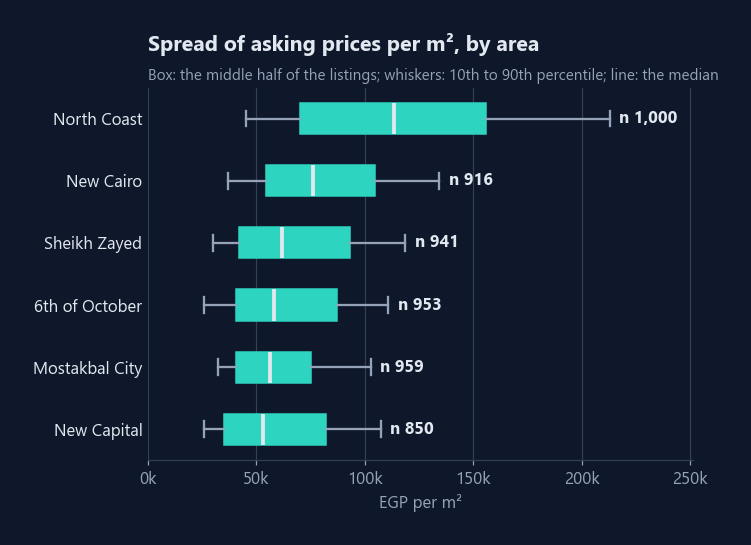

In [28]:
PCTS = {"p10": 0.1, "p25": 0.25, "median": 0.5, "p75": 0.75, "p90": 0.9}
spread = pooled.groupby("area").price_per_m2.agg(n="size", **{k: (lambda q: lambda v: v.quantile(q))(q) for k, q in PCTS.items()})
spread = spread.reset_index()
spread, spread_small = spread[spread.n >= MIN_N], spread[spread.n < MIN_N]
spread = spread.set_index("area").reindex([a for a in area_rank.area if a in set(spread.area)]).reset_index()
assert (spread.set_index("area")["median"].sub(area_rank.set_index("area")["median"]).abs() < 0.006).all(), \
    "insight 10 and insight 1 disagree on an area median"
spread["p90_over_p10_pct"] = (spread.p90 / spread.p10 - 1) * 100
by_spread = spread.sort_values(["p90_over_p10_pct", "area"], ascending=[False, True], ignore_index=True)
wide_s, narrow_s = by_spread.iloc[0], by_spread.iloc[-1]

insights["10"] = dict(
    title="Spread of price per m² in each area",
    grain="one row per area, latest run week, pooled over sites and unit types",
    groups=rows(spread), groups_skipped=len(spread_small), listings_skipped=int(spread_small.n.sum()),
    widest_area=wide_s.area, widest_n=int(wide_s.n), widest_p10_m2=wide_s.p10, widest_p90_m2=wide_s.p90,
    widest_p90_over_p10_pct=wide_s.p90_over_p10_pct,
    narrowest_area=narrow_s.area, narrowest_n=int(narrow_s.n), narrowest_p10_m2=narrow_s.p10, narrowest_p90_m2=narrow_s.p90,
    narrowest_p90_over_p10_pct=narrow_s.p90_over_p10_pct, chart=None,
    sentence=(f"Asking prices per m² spread widest in {wide_s.area}, where the 90th percentile ({egp(wide_s.p90)}) is "
              f"{pct(wide_s.p90_over_p10_pct)}% above the 10th ({egp(wide_s.p10)}, n = {wide_s.n:,}), and narrowest in "
              f"{narrow_s.area}, at {pct(narrow_s.p90_over_p10_pct)}% ({egp(narrow_s.p10)} to {egp(narrow_s.p90)}, "
              f"n = {narrow_s.n:,}); every unit type is in it, so part of a spread is the mix of types; "
              f"{skipped(spread_small, 'area')}."),
)

g = spread.iloc[::-1].reset_index(drop=True)  # the dearest area on top
fig, ax = chart("Spread of asking prices per m², by area",
                "Box: the middle half of the listings; whiskers: 10th to 90th percentile; line: the median")
ax.bxp([dict(label=r.area, med=r["median"], q1=r.p25, q3=r.p75, whislo=r.p10, whishi=r.p90, fliers=[])
        for _, r in g.iterrows()], orientation="horizontal", widths=0.5, showfliers=False, patch_artist=True,
       boxprops=dict(facecolor=SITE_COLOURS[0], edgecolor=SITE_COLOURS[0]), medianprops=dict(color=INK, linewidth=2.5),
       whiskerprops=dict(color=MUTED, linewidth=1.5), capprops=dict(color=MUTED, linewidth=1.5))
for i, r in g.iterrows():
    ax.text(r.p90 + g.p90.max() * 0.02, i + 1, f"n {r.n:,}", va="center", color=INK, fontweight="bold")
ax.set_xlim(0, g.p90.max() * 1.18)
ax.xaxis.set_major_formatter(lambda x, _: f"{x / 1000:,.0f}k")
ax.set_xlabel(f"{CURRENCY} per m²")
bars_look(ax)
insights["10"]["chart"] = save(fig, 10, "price-spread")
print(insights["10"]["sentence"])
spread

### Insight 11. Coverage per site

Grain: one row per site, latest run week, summed over the areas asked (`silver.run_log`, section 3).
The listings the run read (`rows_parsed`) against the results the site's own search pages say they
hold (`stated_total`). The run reads a set number of pages per search (`max_pages` in
`config/client.yaml`), so each site is sampled, not read in full; and each site counts its own way, so
the shares compare a site with itself.

The run reads from 0.1% of the listings Bayut Egypt says it holds in the areas asked (144 of 123,108) to 12.5% of realestate.eg's (1,650 of 13,242): a sample of each site, as it reads a set number of pages per search; 0 of 36 searches gave no stated count.


,source,site,stated_total,rows_parsed,read_pct
0,bayut,Bayut Egypt,123108,144,0.116970
1,propertyfinder,Property Finder Egypt,124083,983,0.792212
2,dubizzle,Dubizzle Egypt,120186,2160,1.797214
3,aqarmap,Aqarmap,41309,813,1.968094
4,nawy,Nawy,18636,1104,5.924018
5,realestate,realestate.eg,13242,1650,12.460353


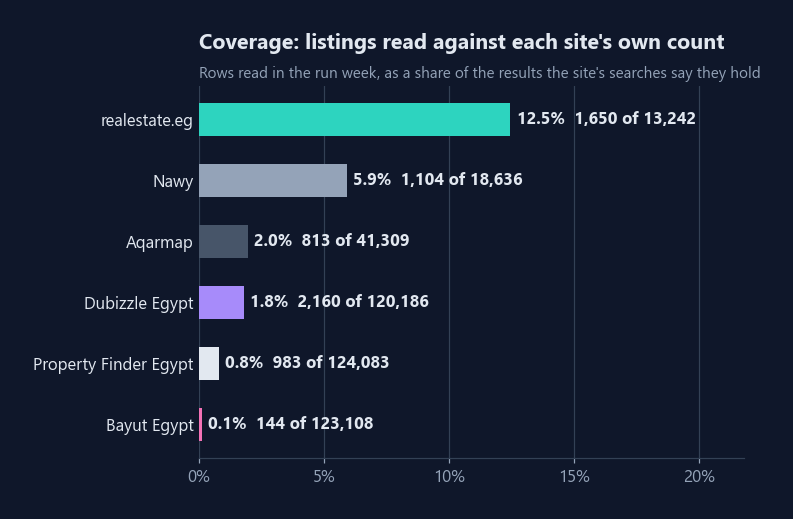

In [29]:
no_total = int(coverage.stated_total.isna().sum())
cov = coverage.dropna(subset=["stated_total"]).groupby(["source", "site"], sort=False)[["stated_total", "rows_parsed"]].sum()
cov = cov.reset_index().astype({"stated_total": int, "rows_parsed": int})
assert len(cov) == numbers["sites_read"] and (cov.stated_total > 0).all(), cov
cov["read_pct"] = cov.rows_parsed / cov.stated_total * 100
cov = cov.sort_values(["read_pct", "site"], ignore_index=True)
low_c, high_c = cov.iloc[0], cov.iloc[-1]

insights["11"] = dict(
    title="Coverage per site", grain="one row per site, latest run week, summed over the areas asked",
    by_site=rows(cov), searches_without_stated_total=no_total,
    lowest_site=low_c.site, lowest_read=int(low_c.rows_parsed), lowest_stated=int(low_c.stated_total), lowest_read_pct=low_c.read_pct,
    highest_site=high_c.site, highest_read=int(high_c.rows_parsed), highest_stated=int(high_c.stated_total),
    highest_read_pct=high_c.read_pct, chart=None,
    sentence=(f"The run reads from {pct(low_c.read_pct)}% of the listings {low_c.site} says it holds in the areas asked "
              f"({low_c.rows_parsed:,} of {low_c.stated_total:,}) to {pct(high_c.read_pct)}% of {high_c.site}'s "
              f"({high_c.rows_parsed:,} of {high_c.stated_total:,}): a sample of each site, as it reads a set number of pages "
              f"per search; {no_total} of {len(coverage)} searches gave no stated count."),
)

fig, ax = chart("Coverage: listings read against each site's own count",
                "Rows read in the run week, as a share of the results the site's searches say they hold")
ax.barh(cov.site, cov.read_pct, height=0.55, color=[colour_of[s] for s in cov.source])
for i, r in cov.iterrows():
    ax.text(r.read_pct + cov.read_pct.max() * 0.02, i, f"{pct(r.read_pct)}%  {r.rows_parsed:,} of {r.stated_total:,}",
            va="center", color=INK, fontweight="bold")
ax.set_xlim(0, cov.read_pct.max() * 1.75)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
ax.xaxis.set_major_formatter(lambda x, _: f"{x:,.0f}%")
bars_look(ax)
insights["11"]["chart"] = save(fig, 11, "coverage")
print(insights["11"]["sentence"])
cov

### Insight 12. Rows set aside, by reason and site

Grain: one cell per site and reason, latest run week. The skipped and duplicate rows are
`silver.run_log` counts (one row per site and area asked, summed per site); the quarantined rows are
`silver.quarantine` rows (one per rejected row and reason). The warehouse keeps the skipped rows as one
count, "another type or outside our areas", without their reason, so that column is not split. Per
site, the quarantine rows must equal `run_log.rows_quarantined`.

Of 6,854 rows parsed in the run week, 935 were skipped as another type or outside our areas, 121 were duplicates within the run and 41 were quarantined; the most common reason is "price per m² outside 10,000 to 400,000" (29 rows, 16 of them from Property Finder Egypt). The skips are kept as one count, without their reason.


,skipped: another type or outside our areas,duplicate within the run,"price per m² outside 10,000 to 400,000",price missing or <= 0,unknown type
source,,,,,
realestate.eg,714,0,1,0,0
Property Finder Egypt,9,0,16,0,0
Dubizzle Egypt,7,1,2,0,0
Nawy,204,30,8,11,1
Bayut Egypt,1,0,0,0,0
Aqarmap,0,90,2,0,0


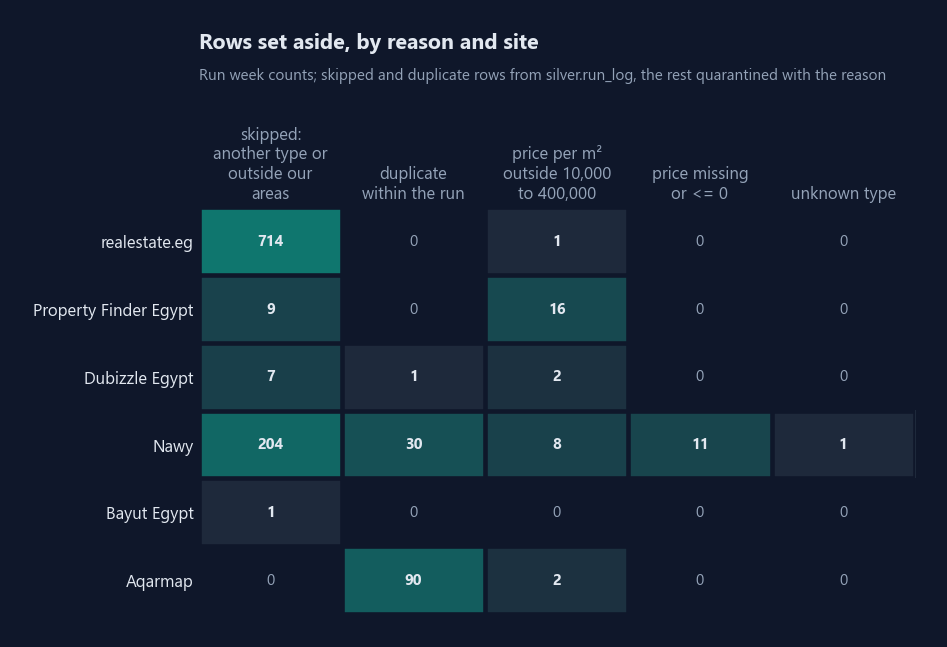

In [30]:
import textwrap

from matplotlib.colors import LogNorm


def count_map(ax, table):
    """Counts per cell on a log colour scale (the counts span three orders of magnitude); a 0 cell stays empty."""
    values = table.to_numpy(dtype=float)
    ax.imshow(np.where(values > 0, values, np.nan), cmap=SEQUENTIAL, norm=LogNorm(vmin=1, vmax=max(values.max(), 2)),
              aspect="auto")
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            ax.text(j, i, f"{int(values[i, j]):,}", ha="center", va="center", color=INK if values[i, j] else MUTED,
                    fontsize=10, fontweight="bold" if values[i, j] else "normal")
    ax.set_xticks(range(values.shape[1]), [textwrap.fill(str(c), 15) for c in table.columns])
    ax.set_yticks(range(values.shape[0]), list(table.index))
    ax.set_xticks(np.arange(-0.5, values.shape[1]), minor=True)
    ax.set_yticks(np.arange(-0.5, values.shape[0]), minor=True)
    ax.grid(which="minor", color=SURFACE, linewidth=3)
    ax.tick_params(which="both", length=0)
    ax.xaxis.tick_top()
    for side in ax.spines.values():
        side.set_visible(False)


SKIPPED, DUPLICATE = "skipped: another type or outside our areas", "duplicate within the run"
week_q = quarantine[quarantine.run_week == latest_week]
per_site = run_log.groupby("source")[["rows_parsed", "rows_skipped", "rows_duplicate", "rows_quarantined"]].sum()
q_wide = week_q.pivot_table(index="source", columns="reason", values="rows", aggfunc="sum", fill_value=0)
assert q_wide.sum(axis=1).reindex(per_site.index, fill_value=0).eq(per_site.rows_quarantined).all(), \
    "silver.quarantine and silver.run_log disagree on a site's rejected rows"
reasons = week_q.groupby("reason").rows.sum().sort_values(ascending=False, kind="stable")
reasons = reasons.loc[sorted(reasons.index, key=lambda r: (-reasons[r], r))]
set_aside = (per_site[["rows_skipped", "rows_duplicate"]].set_axis([SKIPPED, DUPLICATE], axis=1)
             .join(q_wide.reindex(columns=reasons.index)).fillna(0).astype(int)
             .reindex(sites.source, fill_value=0).rename(index=dict(zip(sites.source, sites.name))))
top_reason = reasons.index[0]
top_reason_site = set_aside[top_reason].sort_values(ascending=False, kind="stable")

insights["12"] = dict(
    title="Rows set aside, by reason and site", grain="one cell per site and reason, latest run week",
    by_site=rows(set_aside.reset_index(names="site")), rows_parsed=int(per_site.rows_parsed.sum()),
    rows_skipped=int(per_site.rows_skipped.sum()), rows_duplicate=int(per_site.rows_duplicate.sum()),
    rows_quarantined=int(per_site.rows_quarantined.sum()), reasons={k: int(v) for k, v in reasons.items()},
    top_reason=top_reason, top_reason_rows=int(reasons.iat[0]), top_reason_site=top_reason_site.index[0],
    top_reason_site_rows=int(top_reason_site.iat[0]), chart=None,
    sentence=(f"Of {int(per_site.rows_parsed.sum()):,} rows parsed in the run week, {int(per_site.rows_skipped.sum()):,} were "
              f"skipped as another type or outside our areas, {int(per_site.rows_duplicate.sum()):,} were duplicates within "
              f"the run and {int(per_site.rows_quarantined.sum()):,} were quarantined; the most common reason is "
              f"\"{top_reason}\" ({int(reasons.iat[0]):,} rows, {int(top_reason_site.iat[0]):,} of them from "
              f"{top_reason_site.index[0]}). The skips are kept as one count, without their reason."),
)

fig, ax = plt.subplots(figsize=(8.4, 4.8))
count_map(ax, set_aside)
ax.set_title("Rows set aside, by reason and site", pad=104)
ax.annotate("Run week counts; skipped and duplicate rows from silver.run_log, the rest quarantined with the reason",
            (0, 1), xycoords="axes fraction", xytext=(0, 84), textcoords="offset points", color=MUTED, fontsize=10)
insights["12"]["chart"] = save(fig, 12, "set-aside-by-reason")
print(insights["12"]["sentence"])
set_aside

### Insight 13. Listings per site and unit type

Grain: one cell per site and unit type, latest run week, pooled over sites
(`gold.pooled_listing_price`, without the Bayut Egypt rows that copy a Dubizzle ad). A count, not a
price, so no group is left out.

Apartment is the most listed type, 2,121 of 5,619 pooled listings (37.7%), and the most listed on 6 of 6 sites; Bayut Egypt has the fewest pooled listings (5).


unit_type,Apartment,Villa,Town House,Chalet,Twin House,Penthouse,Studio,Duplex,iVilla,Cabin,Loft
name,,,,,,,,,,,
realestate.eg,300,189,94,122,71,35,56,68,0,0,0
Property Finder Egypt,500,180,93,82,42,20,0,24,17,0,0
Dubizzle Egypt,786,607,246,179,164,36,26,45,61,0,0
Nawy,400,130,98,53,55,16,20,63,0,9,6
Bayut Egypt,3,1,0,0,0,1,0,0,0,0,0
Aqarmap,132,119,88,26,110,128,118,0,0,0,0


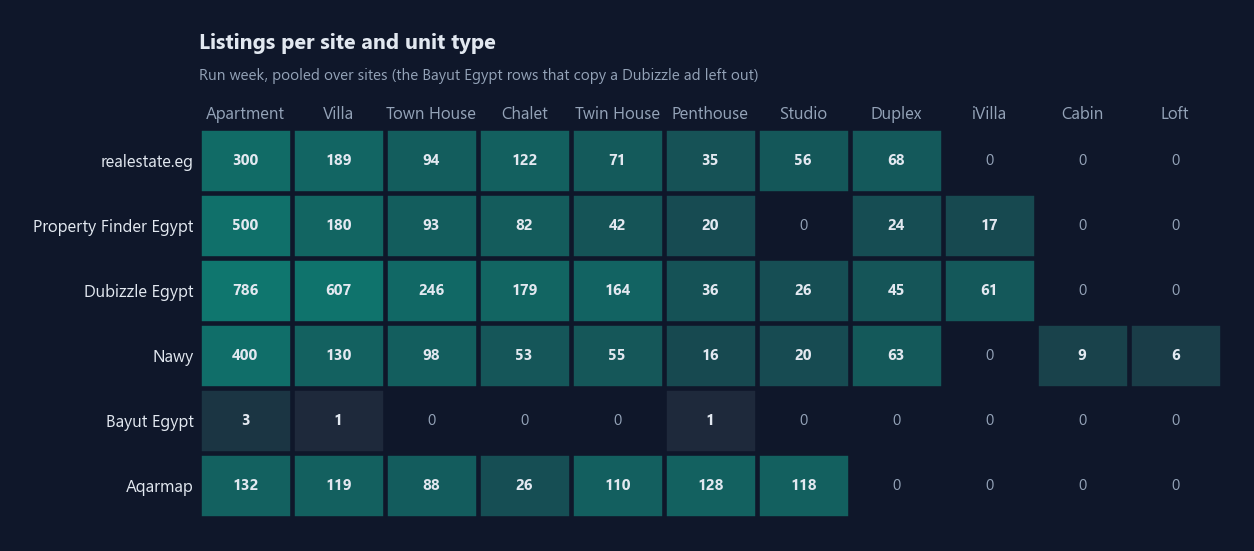

In [31]:
mix = pooled.groupby(["site", "unit_type"]).size().unstack(fill_value=0)
type_cols = sorted(mix.columns, key=lambda t: (-mix[t].sum(), t))  # the most listed type first
mix = mix.reindex(index=sites.name, columns=type_cols, fill_value=0)
assert mix.values.sum() == numbers["pooled_listings"]
top_type = type_cols[0]
top_on = int((mix.idxmax(axis=1) == top_type).sum())
fewest = mix.sum(axis=1).sort_values(kind="stable")

insights["13"] = dict(
    title="Listings per site and unit type", grain="one cell per site and unit type, latest run week, pooled over sites",
    by_site={site: {t: int(n) for t, n in r.items()} for site, r in mix.iterrows()},
    top_type=top_type, top_type_listings=int(mix[top_type].sum()), top_type_pct=mix[top_type].sum() / mix.values.sum() * 100,
    top_type_sites=top_on, sites=len(mix), fewest_site=fewest.index[0], fewest_site_listings=int(fewest.iat[0]), chart=None,
    sentence=(f"{top_type} is the most listed type, {int(mix[top_type].sum()):,} of {int(mix.values.sum()):,} pooled listings "
              f"({pct(mix[top_type].sum() / mix.values.sum() * 100)}%), and the most listed on {top_on} of {len(mix)} sites; "
              f"{fewest.index[0]} has the fewest pooled listings ({int(fewest.iat[0]):,})."),
)

fig, ax = plt.subplots(figsize=(12, 4.6))
count_map(ax, mix)
ax.set_title("Listings per site and unit type", pad=52)
ax.annotate("Run week, pooled over sites (the Bayut Egypt rows that copy a Dubizzle ad left out)",
            (0, 1), xycoords="axes fraction", xytext=(0, 32), textcoords="offset points", color=MUTED, fontsize=10)
insights["13"]["chart"] = save(fig, 13, "site-and-type")
print(insights["13"]["sentence"])
mix

### Insight 14. Each of our units against its market

Grain: one row per unit of ours (generated, see the note before section 5), latest run week: its
`gap_pct` in `gold.unit_gap`, against the pooled median of the same type in the same area. One dot per
unit; the dots of an area are spread up and down by a fixed seed so they do not hide each other, and
the white line is the area's median gap (`gold.area_gap`).

35 of our 60 generated units ask more per m² than the median of their type in their area and 25 the same or less (0 without a comparison); the gaps run from -14.9% (NCO-CH-05) to +15.0% (NC-VIL-02).


,unit_code,area,unit_type,price_per_m2,median_price_per_m2,gap_pct
0,CAP-APT-01,New Capital,Apartment,33300.00,38122.64,-12.65
1,CAP-APT-02,New Capital,Apartment,38818.18,38122.64,1.82
2,CAP-APT-03,New Capital,Apartment,37655.17,38122.64,-1.23
3,CAP-APT-04,New Capital,Apartment,35947.37,38122.64,-5.71
4,CAP-DUP-01,New Capital,Duplex,35921.57,36353.62,-1.19
5,CAP-PH-01,New Capital,Penthouse,57904.76,51822.65,11.74
6,CAP-TH-01,New Capital,Town House,87176.47,78530.61,11.01
7,CAP-TW-01,New Capital,Twin House,85700.00,78571.43,9.07
8,CAP-VIL-01,New Capital,Villa,96296.30,85600.00,12.50
9,CAP-VIL-02,New Capital,Villa,87243.90,85600.00,1.92


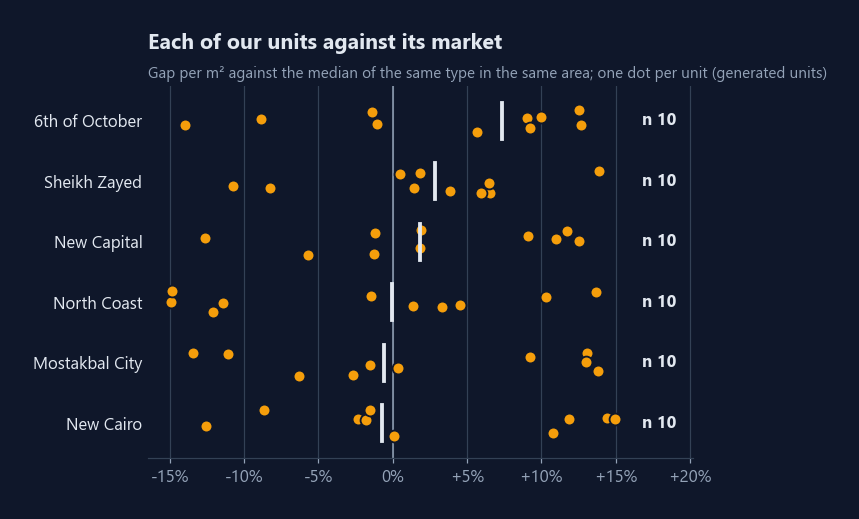

In [32]:
dots = units.dropna(subset=["gap_pct"]).sort_values("unit_code", ignore_index=True)
area_order = list(area_gap.sort_values(["median_gap_pct", "area"]).area)  # the highest median gap on top
lowest_u = dots.sort_values(["gap_pct", "unit_code"]).iloc[0]
highest_u = dots.sort_values(["gap_pct", "unit_code"], ascending=[False, True]).iloc[0]

insights["14"] = dict(
    title="Each of our units against its market", grain="one row per unit of ours (generated units), latest run week",
    units=len(units), units_compared=len(dots), units_without_comparison=int(units.gap_pct.isna().sum()),
    units_above=int((dots.gap_pct > 0).sum()), units_at_or_below=int((dots.gap_pct <= 0).sum()),
    lowest_unit=lowest_u.unit_code, lowest_gap_pct=lowest_u.gap_pct, highest_unit=highest_u.unit_code,
    highest_gap_pct=highest_u.gap_pct, chart=None,
    sentence=(f"{int((dots.gap_pct > 0).sum())} of our {len(units)} generated units ask more per m² than the median of their "
              f"type in their area and {int((dots.gap_pct <= 0).sum())} the same or less "
              f"({int(units.gap_pct.isna().sum())} without a comparison); the gaps run from "
              f"{pct(lowest_u.gap_pct, signed=True)}% ({lowest_u.unit_code}) to {pct(highest_u.gap_pct, signed=True)}% "
              f"({highest_u.unit_code})."),
)

jitter = np.random.default_rng(0).uniform(-0.22, 0.22, len(dots))
fig, ax = chart("Each of our units against its market",
                "Gap per m² against the median of the same type in the same area; one dot per unit (generated units)")
ax.axvline(0, color=MUTED, linewidth=1)
ax.scatter(dots.gap_pct, dots.area.map(area_order.index) + jitter, s=60, color=OURS, edgecolors=SURFACE, linewidths=1.2,
           zorder=3)
span = dots.gap_pct.abs().max()
for i, area in enumerate(area_order):
    median = area_gap.set_index("area").median_gap_pct[area]
    ax.plot([median] * 2, [i - 0.3, i + 0.3], color=INK, linewidth=2.5, zorder=4)
    ax.text(span * 1.12, i, f"n {int((dots.area == area).sum()):,}", va="center", color=INK, fontweight="bold")
ax.set_yticks(range(len(area_order)), area_order)
ax.set_xlim(-span * 1.1, span * 1.35)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:+.0f}%" if x else "0%")
bars_look(ax)
insights["14"]["chart"] = save(fig, 14, "units-against-market")
print(insights["14"]["sentence"])
dots[["unit_code", "area", "unit_type", "price_per_m2", "median_price_per_m2", "gap_pct"]]

In [33]:
for n, item in insights.items():
    print(f"{n}. {item['title']} ({item['chart'] or 'no chart'}): {item['sentence']}\n")

1. Area ranking (docs/insight-1-area-ranking.png): North Coast has the highest median asking price per m² (113,511 EGP, n = 1,000), 114.2% above New Capital, the lowest (53,000 EGP, n = 850); no area skipped.

2. Unit type within each area (docs/insight-2-type-by-area.png): The gap between the dearest and the cheapest unit type is widest in North Coast: Duplex at 171,058 EGP per m² (n = 10) against Apartment at 52,667 EGP (n = 72), 224.8% apart; 9 area and type groups under 10 listings skipped (24 listings).

3. Developer premium (docs/insight-3-developer-index.png): Of 48 developers with 10 or more listings, ADD Properties has the highest index, 219 (n = 12), and Amer Group the lowest, 62 (n = 16), where 100 is the median asking price per m² of the listing's area; developers are named on Aqarmap, Nawy and realestate.eg only, and 259 developers under 10 listings skipped (1,002 listings).

4. Compound ranking (docs/insight-4-compounds.png): Inside one area the spread between the dearest

## 13. The Power BI checks

Each check in `powerbi/06-checks.md` gives the numbers a report page must show and the SQL that
gives them, on the gold layer as the report reads it. This section runs that SQL as printed (read
from the file, so the two cannot drift) and keeps each value in `numbers` for the file's slots.
Where a value already has a key above, the check's SQL must agree with it. Two keys look alike and
differ: the cuts and rises of C14 count every run week (`price_cuts` counts the latest one only),
and the compounds and developers of C9 count the latest run week (`compounds_covered` counts any
week). The report loads `gold.pooled_listing_price`, the listings pooled over sites without the
Bayut Egypt rows that copy a Dubizzle ad, as the README does: so the listing counts of the checks
equal `pooled_listings` and the cheaper shares of C3 and C7 equal the keys of section 6.
C16 and C17 need a price change, so they hold "(Blank)" and "no rows yet" until the second weekly run.


In [34]:
checks_md = (ROOT / "powerbi" / "06-checks.md").read_text(encoding="utf-8")
CHECK_SQL = dict(re.findall(r"\*\*(C\d+)\.\*\*.*?```sql\n(.*?)```", checks_md, re.S))
assert list(CHECK_SQL) == [f"C{i}" for i in range(1, 19)], list(CHECK_SQL)


def check_sql(name):
    return "\n".join(line for line in CHECK_SQL[name].splitlines() if not line.lstrip().startswith("--"))


def check(name):
    """The rows of each statement under a check, run as printed."""
    return [query(statement) for statement in check_sql(name).split(";") if statement.strip()]


c1 = check("C1")[0].iloc[0]
assert (int(c1.run_weeks), c1.latest_week, int(c1.prices_latest_week)) == (
    numbers["run_weeks"], latest_week, numbers["pooled_listings"]), c1

c2 = check("C2")[0].iloc[0]
numbers.update({f"table_rows_{table}": int(n) for table, n in c2.items()})

c3 = check("C3")[0].iloc[0]
assert (int(c3.our_units), c3.widest_gap_area, int(c3.listings)) == (
    numbers["our_units"], numbers["widest_gap_area"], numbers["pooled_listings"]), c3
assert (int(c3.listings_in_our_types), int(c3.listings_cheaper), pct(c3.share_cheaper_pct)) == (
    numbers["listings_in_our_types"], numbers["listings_cheaper_than_ours"], pct(numbers["share_listings_cheaper_than_ours"])), c3
numbers.update(units_above_market_pct=float(c3.share_above_pct), units_below_market_pct=float(c3.share_below_pct))

c4 = check("C4")[0].dropna(subset=["median_gap_pct"])
numbers["area_bar_labels"] = ", ".join(f"{r['name']} {pct(r.median_gap_pct)}%" for _, r in c4.iterrows())

c5 = check("C5")[0]
bubbles = c5[(c5.listings > 0) & c5.lat.notna() & c5.lon.notna()]
assert len(bubbles) == 1 or bubbles.listings.iat[0] > bubbles.listings.iat[1], "two areas tie for the biggest bubble"
numbers.update(map_bubbles=len(bubbles), map_biggest_area=bubbles["name"].iat[0])

c6_top, c6_count = check("C6")
assert (int(c6_count.units[0]), int(c6_count.no_comparison[0])) == (numbers["our_units"], numbers["units_without_comparison"])
numbers["units_top_by_gap"] = ", ".join(f"{r.unit_code} ({pct(r.gap_pct)}%)" for _, r in c6_top.iterrows())

# C7, C13 and C18 slice on report.check_area, which the pipeline sets on the database (client.check_area).
check_area = cfg["report"]["check_area"]
assert query("SELECT current_setting('client.check_area') AS a").a[0] == check_area, "run the pipeline after changing report.check_area"
c7 = check("C7")[0].iloc[0]
assert (int(c7.listings), pct(c7.share_cheaper_pct)) == (
    numbers["pooled_listings_by_area"][slot(check_area)], pct(numbers[f"share_cheaper_{slot(check_area)}"])), c7
numbers.update(check_area_name=next(a["name"] for a in cfg["areas"] if a["id"] == check_area),
               check_area_our_units=int(c7.our_units), check_area_units_above_pct=float(c7.share_above_pct),
               check_area_units_below_pct=float(c7.share_below_pct), check_area_listings=int(c7.listings),
               check_area_share_cheaper_pct=numbers[f"share_cheaper_{slot(check_area)}"])

c8 = check("C8")[0].iloc[0]
assert (int(c8.our_units), int(c8.listings)) == (numbers["our_units"], numbers["listings_by_site"]["dubizzle"]), c8
numbers.update(dubizzle_units_above_pct=float(c8.share_above_pct),
               dubizzle_units_below_pct=float(c8.share_below_pct), dubizzle_share_cheaper_pct=float(c8.share_cheaper_pct),
               dubizzle_widest_gap_area=c8.widest_gap_area, dubizzle_listings=int(c8.listings))

c9 = check("C9")[0].iloc[0]
assert int(c9.listings) == numbers["pooled_listings"], c9
numbers.update(compounds_latest_week=int(c9.compounds), developers_latest_week=int(c9.developers),
               cheapest_compound=c9.cheapest_compound, dearest_compound=c9.dearest_compound)

numbers["matrix_first_compounds"] = ", ".join(dict.fromkeys(check("C10")[0].compound))
numbers["dearest_developers"] = ", ".join(check("C11")[0].developer)
numbers["band_table_top_rows"] = ", ".join(f"{r.area} {r.unit_type} ({int(r.listings):,} listings)"
                                           for _, r in check("C12")[0].iterrows())

c13 = check("C13")[0].iloc[0]
assert int(c13.listings) == numbers["check_area_listings"], c13
numbers.update(check_area_compounds=int(c13.compounds), check_area_developers=int(c13.developers),
               check_area_cheapest_compound=c13.cheapest_compound, check_area_dearest_compound=c13.dearest_compound)

c14 = check("C14")[0].iloc[0]
assert (int(c14.price_changes), int(c14.listings)) == (numbers["price_changes"], numbers["pooled_listings"]), c14
numbers.update(cuts_all_weeks=int(c14.cuts), rises_all_weeks=int(c14.rises),
               average_change_pct=None if pd.isna(c14.average_change_pct) else float(c14.average_change_pct))

numbers["weeks_with_changes"] = len(check("C15")[0])

c17 = check("C17")[0]
assert len(c17) == min(5, numbers["price_changes"])
numbers["deepest_cuts"] = ", ".join(f"{r.listing_id} on {r.site} ({pct(r.change_pct)}%)"
                                    for _, r in c17.iterrows()) or "no rows yet"
deepest = {"deepest_cut_old_m2": None, "deepest_cut_new_m2": None, "deepest_cut_ours_m2": None}
if len(c17):  # C16 is printed for 'dubizzle' and listing '0': run it for the deepest cut of C17
    cut = c17.iloc[0]
    source = query("SELECT source FROM gold.dim_site WHERE name = %s", cut.site).source[0]
    sql = check_sql("C16").replace("'dubizzle'", "%s").replace("'0'", "%s").strip().rstrip(";")
    c16 = query(sql, source, cut.listing_id).set_index("week_key")
    deepest = {"deepest_cut_old_m2": float(c16.price_per_m2[cut.old_week_key]),
               "deepest_cut_new_m2": float(c16.price_per_m2[cut.week_key]),
               "deepest_cut_ours_m2": None if pd.isna(c16.ours_same_type_per_m2.iat[0]) else float(c16.ours_same_type_per_m2.iat[0])}
numbers.update(deepest)

c18 = check("C18")[0].iloc[0]
assert int(c18.listings) == numbers["check_area_listings"], c18
numbers.update(check_area_price_changes=int(c18.price_changes), check_area_cuts=int(c18.cuts),
               check_area_rises=int(c18.rises))
print(f"18 checks run; {len(c2)} tables counted; {numbers['area_bar_labels']}")


18 checks run; 12 tables counted; 6th of October 7.4%, Sheikh Zayed 2.8%, New Capital 1.9%, North Coast -0.1%, Mostakbal City -0.6%, New Cairo -0.7%


## 14. The card's numbers

Every slot is written as `docs/notebook-slots.md` says: counts with thousands separators,
percentages to one decimal (signed for a gap), prices per m² in whole EGP, dates like 4 October 2026. A text value (an area, a phrase such as
"1 weekly run", or a list of rows for a Power BI check) is written as it is, and a value the
warehouse has not got yet is written "(Blank)", as Power BI shows it.
`numbers.json` keeps the unrounded values; the text is formatted from it.

In [35]:
def slot_text(key, values):
    value = values[key]
    if value is None:
        return "(Blank)"
    if key in ("first_run_week", "latest_run_week"):
        day = date.fromisoformat(value)
        return f"{day.day} {day:%B %Y}"
    if isinstance(value, str):
        return value
    if key == "widest_gap_pct" or key.startswith("gap_pct_"):
        return pct(value, signed=True)
    if key.endswith("_pct") or key.startswith("share_"):
        return pct(value)
    if key.endswith("_index"):
        return f"{half_up(value, 0):,}"
    if key == "live_read_minutes_estimate" or "_m2" in key:
        return f"{half_up(value, 0):,}"
    return f"{value:,}"


s = {key: slot_text(key, numbers) for key in ("listings_compared", "sites_read", "areas_read", "compounds_covered",
                                               "developers_covered", "widest_gap_pct", "widest_gap_area",
                                               "quarantined_rows", "quarantine_share_pct")}
numbers["card_title"] = f"Our asking price per m² against {s['listings_compared']} competing listings, every week"
numbers["card_result"] = (f"{s['listings_compared']} competing listings from {s['sites_read']} sites in {s['areas_read']} "
                          f"areas read and checked, {s['compounds_covered']} compound names and {s['developers_covered']} "
                          f"developers covered; our units' widest gap is {s['widest_gap_pct']}% in {s['widest_gap_area']}, "
                          f"and {s['quarantined_rows']} rows ({s['quarantine_share_pct']}%) were set aside with their reason.")
assert CURRENCY not in numbers["card_title"] + numbers["card_result"], "the card carries no price"
(ROOT / "analysis" / "numbers.json").write_text(json.dumps(numbers, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
print("Title: ", numbers["card_title"])
print("Result:", numbers["card_result"])

Title:  Our asking price per m² against 5,619 competing listings, every week
Result: 5,619 competing listings from 6 sites in 6 areas read and checked, 1,152 compound names and 307 developers covered; our units' widest gap is +7.4% in 6th of October, and 41 rows (0.7%) were set aside with their reason.


## 15. Write the README, the checks and the pictures from numbers.json

Every `<!--nb:KEY-->…<!--/nb-->` slot in README.md, powerbi/06-checks.md and powerbi/08-build-checklist.md and every `<tspan id="nb-KEY">` in the two SVGs
is filled from `numbers.json` (an insight's value is the slot `i<n>_<key>`, from `insights`); the markers stay, so the next run refreshes them. In
`price-gap-by-area.svg` the band, the median tick and our units' dots of each area are moved to their
prices on the shared scale (the track runs from x 230 to x 690); nothing else in the file changes.

In [36]:
values = json.loads((ROOT / "analysis" / "numbers.json").read_text(encoding="utf-8"))
values.update({f"i{n}_{key}": value for n, item in values["insights"].items() for key, value in item.items()
               if not isinstance(value, (dict, list))})
X0, X1 = 230, 690


def x_of(m2):
    return round(X0 + (m2 - values["scale_min_m2"]) / (values["scale_max_m2"] - values["scale_min_m2"]) * (X1 - X0), 1)


def fill(path, pattern, replace):
    text = path.read_bytes().decode("utf-8")
    found = re.findall(pattern, text)
    assert found, f"no slot in {path.name}"
    path.write_bytes(re.sub(pattern, replace, text).encode("utf-8"))
    return len(found)


# docs/price-gap-by-area.svg draws one strip per area: it is redrawn only when its strips are this config's
# areas. Another client's areas need their strips drawn once by hand.
svg_path = ROOT / "docs" / "price-gap-by-area.svg"
area_names = {a["id"]: a["name"] for a in cfg["areas"]}
strips = sorted(re.findall(r'class="area">([^<]+)</text>', svg_path.read_bytes().decode("utf-8")))
draw_strips = strips == sorted(area_names.values())
if not draw_strips:
    print(f"price-gap-by-area.svg draws {strips}, not this config's areas: not redrawn")

written = {
    path.name: fill(path, r"<!--nb:(\w+)-->.*?<!--/nb-->", lambda m: f"<!--nb:{m[1]}-->{slot_text(m[1], values)}<!--/nb-->")
    for path in (ROOT / "README.md", ROOT / "powerbi" / "06-checks.md", ROOT / "powerbi" / "08-build-checklist.md")
}
for name in ("header.svg", "price-gap-by-area.svg") if draw_strips else ("header.svg",):
    written[name] = fill(ROOT / "docs" / name, r'<tspan id="nb-(\w+)">[^<]*</tspan>',
                         lambda m: f'<tspan id="nb-{m[1]}">{slot_text(m[1], values)}</tspan>')

svg = svg_path.read_bytes().decode("utf-8")
for area_id in area_names if draw_strips else ():
    block = re.search(rf"  <!-- {re.escape(area_names[area_id])} -->\r?\n.*?(?=\r?\n\s*<!--)", svg, re.S)
    assert block, f"no strip for {area_names[area_id]} in the SVG"
    part = block[0]
    y = float(re.search(r'<line x1="[^"]*" y1="([\d.]+)" x2="[^"]*" y2="[^"]*" class="track"/>', part)[1])
    p25, p75, median = (x_of(values[f"{k}_m2_{slot(area_id)}"]) for k in ("p25", "p75", "median"))
    part = re.sub(r'<rect x="[^"]*"( y="[^"]*") width="[^"]*"( height="[^"]*" rx="[^"]*" class="band"/>)',
                  rf'<rect x="{p25:g}"\1 width="{round(p75 - p25, 1):g}"\2', part)
    part = re.sub(r'<line x1="[^"]*"( y1="[^"]*") x2="[^"]*"( y2="[^"]*" class="median"/>)',
                  rf'<line x1="{median:g}"\1 x2="{median:g}"\2', part)
    part = re.sub(r'\n  <circle [^>]*class="ours"/>', "", part)
    dots = "".join(f'\n  <circle cx="{x_of(m2):g}" cy="{y:g}" r="7" class="ours"/>' for m2 in values[f"our_units_m2_{slot(area_id)}"])
    part = re.sub(r'(<line [^>]*class="median"/>)', lambda m: m[1] + dots, part)
    svg = svg[:block.start()] + part + svg[block.end():]
svg_path.write_bytes(svg.encode("utf-8"))
print(written)

{'README.md': 47, '06-checks.md': 71, '08-build-checklist.md': 17, 'header.svg': 5, 'price-gap-by-area.svg': 20}


## 16. Every slot filled

Each slot is parsed back out of the files: none may still hold the placeholder `…`, and every key
must be in `numbers.json`.

In [37]:
left_empty = {}
for path in (ROOT / "README.md", ROOT / "powerbi" / "06-checks.md", ROOT / "powerbi" / "08-build-checklist.md",
             ROOT / "docs" / "header.svg", *([svg_path] if draw_strips else [])):
    text = path.read_bytes().decode("utf-8")
    assert "[from the notebook]" not in text, f"{path.name} still has a value to fill"
    slots = re.findall(r"<!--nb:(\w+)-->(.*?)<!--/nb-->", text) + re.findall(r'<tspan id="nb-(\w+)">([^<]*)</tspan>', text)
    assert all(key in values for key, _ in slots)
    left_empty[path.name] = [key for key, value in slots if value in ("", "…")]
    print(f"{path.name}: {len(slots)} slots, {len(left_empty[path.name])} unfilled")
assert not any(left_empty.values()), left_empty
for name in ("listings-by-area.png", "gap-by-area.png", "price-cuts-by-week.png"):
    assert (ROOT / "docs" / name).stat().st_size > 0
for item in values["insights"].values():
    assert item["chart"] is None or (ROOT / item["chart"]).stat().st_size > 0, item["chart"]
conn.close()

README.md: 47 slots, 0 unfilled
06-checks.md: 71 slots, 0 unfilled
08-build-checklist.md: 17 slots, 0 unfilled
header.svg: 5 slots, 0 unfilled
price-gap-by-area.svg: 20 slots, 0 unfilled
